# ICMS 150 (June 1 experiment)

- Closed loop plan: day 1: perform visual (16 orientations, 100 trials) and electrical (3000 patterns, 50 oracles x 20 trials). This notebook is used after output spike sorting and curation to fit stimulus-encoder TCN model and generate stimualtion patterns for each orientation to try on day 2. 


Visual stim duration: 0.5s ON, 0.5s OFF
Velocity(temporal frequency): 3Hz
Width (spatial frequency): 0.05 cycle/degree
After that is 4000 patterns, 3000 samples appear 1 times, 50 oracle samples repeating 20 times


In [2]:
import sys
sys.path.insert(0, '../patterns_5k')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils import read_pattern_json, preprocess_pattern_stimulations_df
%load_ext autoreload
%autoreload 2
datadir = "data/icms_150_4_4_26"

all_spikes = np.load(f"{datadir}/All_Shank_Spk_Vecs.npy", allow_pickle=False) # contains each spike indexed with (sample index, unit index, segment index)
spikes_df = pd.DataFrame(all_spikes)  # columns auto-named from dtype fields
spikes_df.rename(columns={'sample_index': 'timestamp', 'unit_index': 'neuron_id'}, inplace=True)
spikes_df.drop(columns=['segment_index'], inplace=True)

pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(read_pattern_json(f"{datadir}/Combined_Pattern_Registrations.pkl"), align_to_stim=True)
pattern_df = pattern_df.drop_duplicates()

visual_stim_times = np.load(f"{datadir}/VStim_Onset_TS.npy") * 30 # 1600
visual_stim_labels = np.load(f"{datadir}/VStim_Labels.npy") # 1600 

visual_orientation_degs = np.sort(np.unique(visual_stim_labels))
visual_trial_df = pd.DataFrame({
    'timestamp': visual_stim_times,
    'orientation': visual_stim_labels
})
min_visual_timestamp = visual_trial_df['timestamp'].min()
max_visual_timestamp = visual_trial_df['timestamp'].max()

visual_spikes = spikes_df[(spikes_df['timestamp'] >= min_visual_timestamp) & (spikes_df['timestamp'] <= max_visual_timestamp)].copy()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:

# --- Timing constants -------------------------------------------------
# Spike timestamps are in *samples* at SAMPLE_RATE Hz. The visual stimulus
# was shown for STIM_MS ms, so we bin the full stim window (no data is
# thrown away). The window is chopped into bins of BIN_MS ms.
SAMPLE_RATE    = 30_000                       # Hz
STIM_MS        = 500                          # stimulus duration (ms)
BIN_MS         = 10                           # PSTH bin width (ms)

SAMPLES_PER_MS = SAMPLE_RATE // 1000          # 30 samples / ms
WINDOW_LEN     = STIM_MS * SAMPLES_PER_MS     # 500 ms -> 15000 samples
BIN_SAMPLES    = BIN_MS  * SAMPLES_PER_MS     # 50 ms  -> 1500 samples
N_BINS         = WINDOW_LEN // BIN_SAMPLES    # STIM_MS / BIN_MS
assert WINDOW_LEN % BIN_SAMPLES == 0, "BIN_MS must evenly divide STIM_MS"

N_VIS_TRIALS = 100

all_neuron_ids = np.sort(visual_spikes['neuron_id'].unique())
n_neurons = len(all_neuron_ids)
neuron_to_idx = {n: i for i, n in enumerate(all_neuron_ids)}

sum_responses = []
for orientation in visual_orientation_degs:
    sum_response = np.zeros((n_neurons, N_BINS))
    for trial in range(N_VIS_TRIALS):
        trial_time = visual_trial_df[visual_trial_df['orientation'] == orientation].iloc[trial]['timestamp']
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= trial_time) &
                                     (visual_spikes['timestamp'] <  trial_time + WINDOW_LEN)]
        if trial_spikes.empty:
            continue
        bin_edges = trial_time + np.arange(N_BINS + 1) * BIN_SAMPLES  # N_BINS+1 edges across STIM_MS

        for neuron_id in trial_spikes['neuron_id'].unique():
            idx = neuron_to_idx[neuron_id]
            counts, _ = np.histogram(
                trial_spikes[trial_spikes['neuron_id'] == neuron_id]['timestamp'],
                bins=bin_edges,
            )
            sum_response[idx] += counts
    sum_response /= N_VIS_TRIALS  # average over trials 
    sum_responses.append(sum_response) 
sum_responses = np.array(sum_responses)       # (n_orientations, n_neurons, N_BINS)
print (sum_responses.shape)
print(f"Window: {STIM_MS} ms = {WINDOW_LEN} samples at {SAMPLE_RATE} Hz")
print(f"Bins:   {N_BINS} x {BIN_MS} ms ({BIN_SAMPLES} samples each)")
print(f"sum_responses shape (orient, neuron, time_bin): {sum_responses.shape}")


(16, 72, 50)
Window: 500 ms = 15000 samples at 30000 Hz
Bins:   50 x 10 ms (300 samples each)
sum_responses shape (orient, neuron, time_bin): (16, 72, 50)


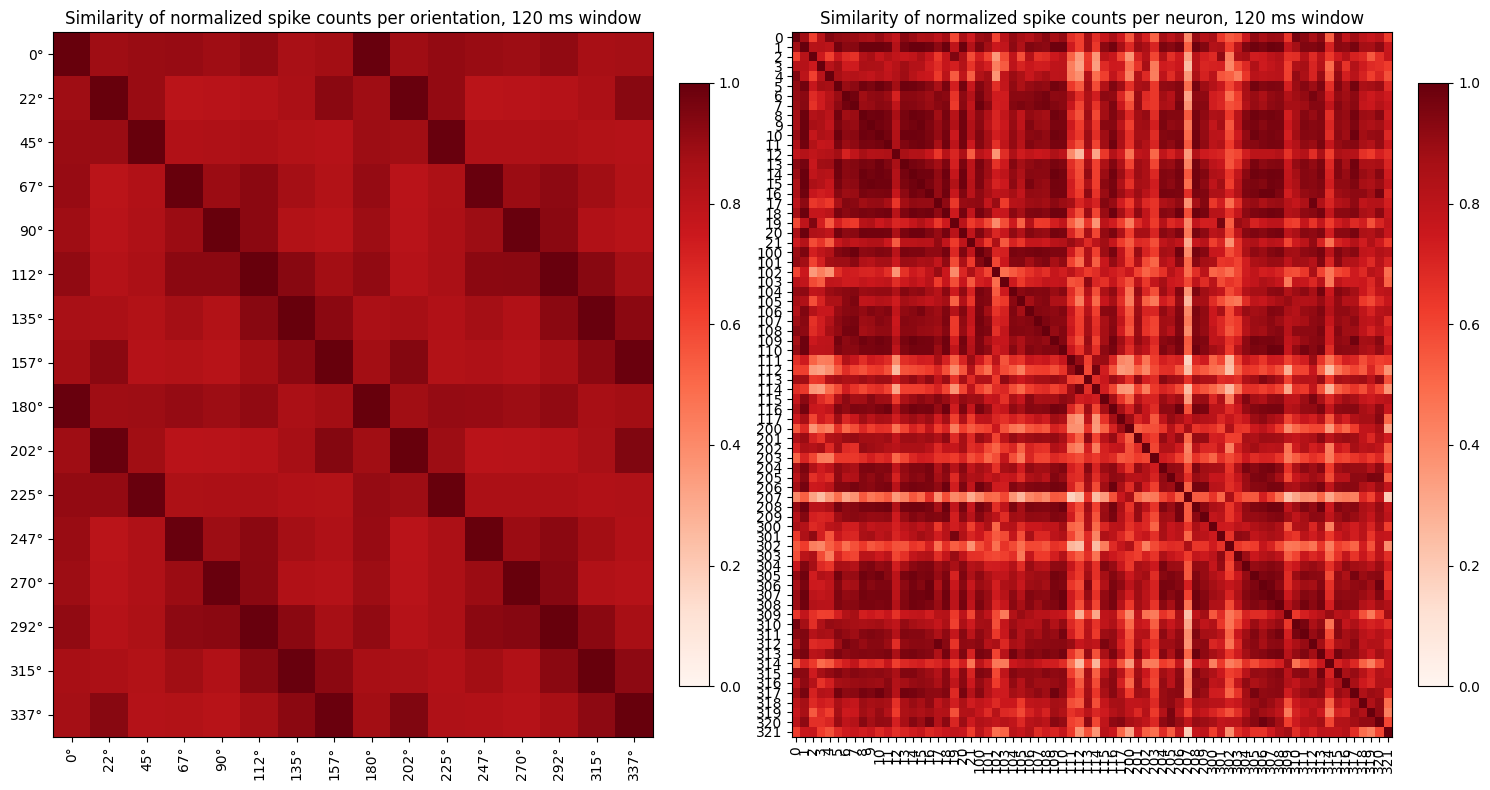

In [4]:
from sklearn.preprocessing import normalize
window = 120 # ms
orient_total = sum_responses[:, :, :window // 10].sum(axis=2)  # (n_orient, n_neurons)
normed_ori = normalize(orient_total, norm='l2')  # each row independently        # (16, n_neurons)
sim_matrix_ori = normed_ori @ normed_ori.T     

normed_neuron = normalize(orient_total.T, norm='l2').T  # each column independently      
sim_matrix_neuron = normed_neuron.T @ normed_neuron

# print (orient_total.shape)
# sim_matrix = orient_total @ orient_total.T                    # (16, 16) cosine similarities

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
im = ax[0].imshow(sim_matrix_ori, vmin=0, vmax=1, cmap='Reds', aspect='auto')
ax[0].set_xticks(range(len(visual_orientation_degs)))
ax[0].set_yticks(range(len(visual_orientation_degs)))
ax[0].set_xticklabels([f'{int(d)}°' for d in visual_orientation_degs], rotation=90)
ax[0].set_yticklabels([f'{int(d)}°' for d in visual_orientation_degs])
ax[0].set_title(f'Similarity of normalized spike counts per orientation, {window} ms window')

ax[1].set_title(f'Similarity of normalized spike counts per neuron, {window} ms window')
ax[1].imshow(sim_matrix_neuron, vmin=0, vmax=1, cmap='Reds', aspect='auto')
ax[1].set_xticks(range(n_neurons))
ax[1].set_yticks(range(n_neurons))
ax[1].set_xticklabels(all_neuron_ids, rotation=90)
ax[1].set_yticklabels(all_neuron_ids)   
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

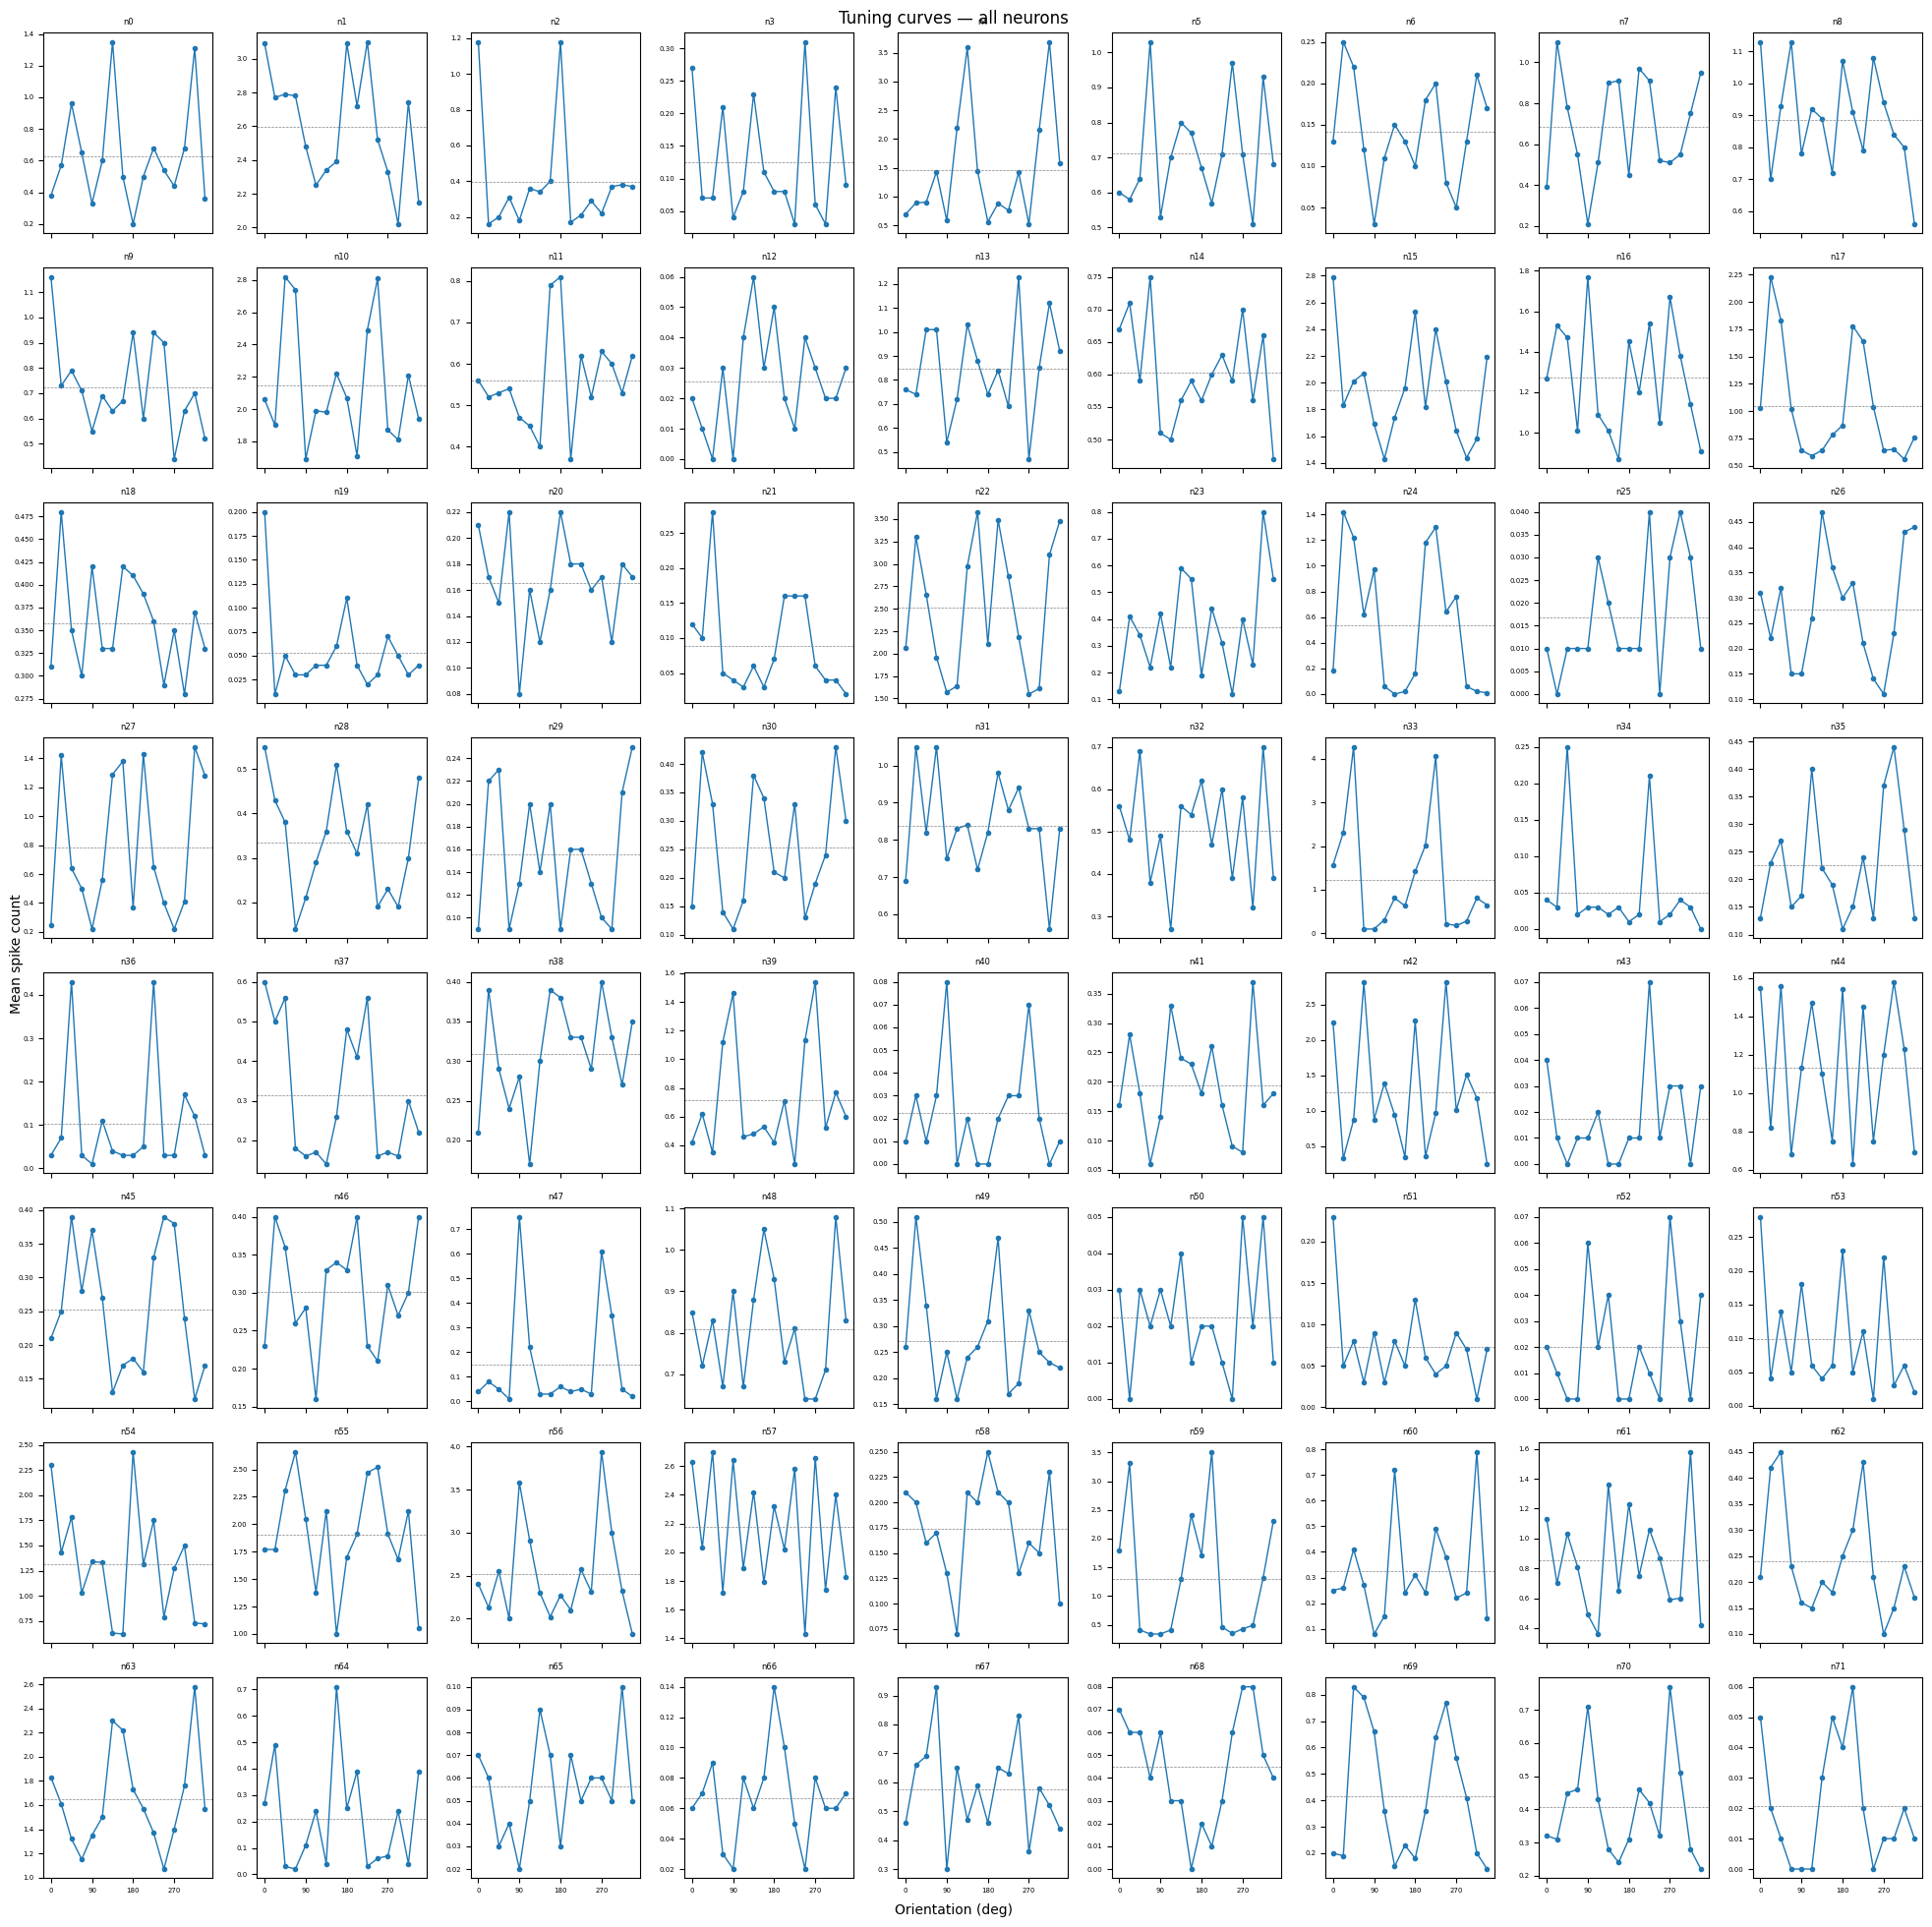

In [5]:
# Tuning curves: mean spike count per orientation, per neuron
fig, axes = plt.subplots(8, 9, figsize=(20, 20), sharex=True)
axes = axes.flatten()

for i, nidx in enumerate(range(72)):
    ax = axes[i]
    ax.plot(visual_orientation_degs, orient_total[:, nidx], 'o-', ms=3, lw=1)
    ax.axhline(orient_total[:, nidx].mean(), color='gray', lw=0.5, linestyle='--')
    ax.set_title(f'n{nidx}', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_xticks(visual_orientation_degs[::4])

for ax in axes[len(range(72)):]:
    ax.set_visible(False)

fig.supxlabel('Orientation (deg)', fontsize=10)
fig.supylabel('Mean spike count', fontsize=10)
fig.suptitle(f'Tuning curves — all neurons', fontsize=12)
plt.tight_layout()
plt.show()


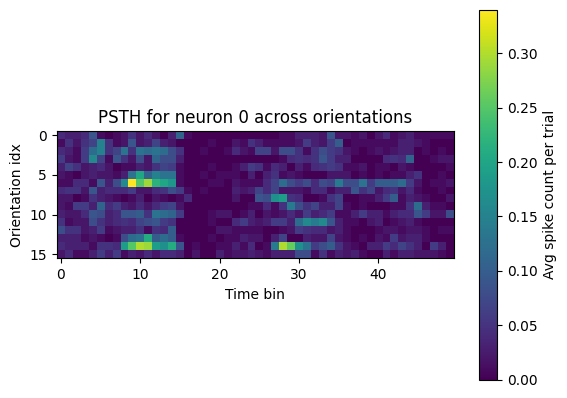

In [6]:
n_idx = 0
plt.imshow(sum_responses[:, n_idx, :])
plt.ylabel("Orientation idx")
plt.xlabel("Time bin")
plt.title(f"PSTH for neuron {n_idx} across orientations")
plt.colorbar(label="Avg spike count per trial")
plt.show()

In [7]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Compute 3-axis projection: [CIS, PC1, PC2]
X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
mean_vec = X.mean(axis=0, keepdims=True)
pca3 = PCA(n_components=2)
pca3.fit(X)
proj, _ = np.linalg.qr(np.array([
    mean_vec[0],
    pca3.components_[0],
    pca3.components_[1],
]).T)                                       # (n_neurons, 3)

coords = X @ proj                           # (n_orientations, 3)  -- averaged points

# ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
trial_coords = []     # (n_orient * n_trials, 3)
trial_doubled = []    # color matches its orientation
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial scatter (low alpha)
fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.05,
                line=dict(width=0)),
    name='Individual trials',
    hovertemplate='trial<extra></extra>',
    showlegend=True,
))

# Orientation-average scatter (full opacity, on top)
fig.add_trace(go.Scatter3d(
    x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='Orientation average',
))

fig.update_layout(
    title='Average Neural Responses to Visual Stimuli',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)
fig.show()


In [8]:
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Compute 3-axis projection: [CIS, PC1, PC2]
X = sum_responses.sum(axis=-1)             # (n_orientations, n_neurons)  -- per-orientation averages
mean_vec = X.mean(axis=0, keepdims=True)
pca3 = PCA(n_components=2)
pca3.fit(X)

coords = X @ pca3.components_.T                           # (n_orientations, 3)  -- averaged points

# ---- Per-trial points: spike counts per (orientation, trial) summed over time bins ----
trial_coords = []     # (n_orient * n_trials, 3)
trial_doubled = []    # color matches its orientation
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + WINDOW_LEN)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ pca3.components_.T)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial scatter (low alpha)
fig.add_trace(go.Scatter(
    x=trial_coords[:, 0], y=trial_coords[:, 1],
    mode='markers',
    marker=dict(size=5, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.05,
                line=dict(width=0)),
    hovertemplate='trial<extra></extra>',
    showlegend=False,
))

# Orientation-average scatter (full opacity, on top)
fig.add_trace(go.Scatter(
    x=coords[:, 0], y=coords[:, 1], 
    mode='markers',
    marker=dict(size=10, color=doubled, colorscale='HSV',
                cmin=0, cmax=360,
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                ),
                line=dict(color='black', width=1)),
    text=[f'{int(o)}°' for o in visual_orientation_degs],
    textposition='top center',
    name='',
    showlegend=False,
))

fig.update_layout(
    title='Trial-averaged Neural Responses to Oriented Visual Stimuli',
    scene=dict(xaxis_title='PC1', yaxis_title='PC2',
               aspectmode='data'),
    width=800, height=700,
)
fig.write_html('results/vis_response_pc1_pc2.html', include_plotlyjs='cdn')
fig.write_image('results/vis_response_pc1_pc2.svg', width=800, height=700, scale=2)
fig.show()




In [9]:
# make a categorical vector of length (1, channels x amplitudes) 1-hot encoded). 
import sys
sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
import os 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from utils import (read_pattern_json, preprocess_pattern_stimulations_df,
                   trial_breakout_spikes_and_patterns, BinnedStimSpikeDataset,
                   NUM_STIM_LEVELS)
from models import SimpleCausalSpikeCNN, train_epoch, validate

# --- Load pattern data (same pipeline as patterns_5k) ---
pattern_df_raw = read_pattern_json(f'{datadir}/Combined_Pattern_Registrations.pkl')
pattern_df, _ = preprocess_pattern_stimulations_df(pattern_df_raw, align_to_stim=True)

# Use the same spikes_df already loaded above
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df['channel'].dropna().unique()))}
spiking_neurons = np.sort(spikes_df['neuron_id'].unique())
spiking_neuron_to_index = {n: i for i, n in enumerate(spiking_neurons)}
n_neurons = len(spiking_neurons)
n_stim_channels = len(channel_to_index)
n_amplitudes = 2 # +- 3 uA
print(f"Stim channels: {n_stim_channels}, Neurons: {n_neurons}")


# --- Config (matching patterns_5k/config.yaml) ---
INPUT_BIN_MS   = 10
OUTPUT_BIN_MS  = 10
N_INPUT_BINS   = 80
N_OUTPUT_BINS  = 80
MAX_TIME_MS    = 720
OUTPUT_OFFSET  = 0
ENCODING_MODE  = 'current'
SEED = 42
np.random.seed(SEED)

pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df, pattern_df, channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
        stim_time_ms=MAX_TIME_MS,
    )
)
print(f"Unique patterns: {len(pattern_stims)}, Total trials: {len(spike_responses)}")


# --- Train/val/test split: oracle patterns as test ---
unique_trials_info = pattern_df[['pattern_timing_index','pattern_name','is_oracle']].drop_duplicates()
oracle_timing    = unique_trials_info[unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
non_oracle_timing = unique_trials_info[~unique_trials_info['is_oracle']]['pattern_timing_index'].tolist()
train_indices = non_oracle_timing
test_indices  = oracle_timing


Stim channels: 40, Neurons: 72
Unique patterns: 3100, Total trials: 4000


In [10]:
# ============================================================
# Prepare stim->spike datasets + loaders for model evaluation.
#   - inputs : per-electrode current ('current' encoding), 10 ms bins, +-3 amps
#   - targets: per-neuron spike counts, 10 ms bins
#   - train  : non-oracle trials (90/10 train/val split)
#   - test   : oracle trials
#   - stim channels only (no init state, no spike history)
#
# NOTE: the model is no longer trained here -- it is selected by the
# hyperparameter-optimization cell below (`best_model`). This cell only
# builds the datasets/loaders and the loss used to score the model.
# ============================================================
import os, sys, json, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

sys.path.insert(0, '/Users/shubhom/Documents/closed_loop_stim/patterns_5k')
from utils  import BinnedStimSpikeDataset
from models import SimpleCausalSpikeCNN

device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps'  if torch.backends.mps.is_available() else
                      'cpu')
print('device:', device)

# Base binning config. Architecture/training hyperparameters are chosen by
# the HP-opt cell; `CFG` is overwritten there from the winning trial.
MAX_TIME_MS = 600
CFG = dict(
    INPUT_BIN_MS  = 10,
    OUTPUT_BIN_MS = 10,
    N_INPUT_BINS  = MAX_TIME_MS // 10,
    N_OUTPUT_BINS = MAX_TIME_MS // 10,
    MAX_TIME_MS   = MAX_TIME_MS,
    ENCODING_MODE = 'current',
    BATCH_SIZE    = 16,
    VAL_FRAC      = 0.2,
    SEED          = 42,
)

# --- datasets (non-oracle -> train+val, oracle -> test) ---
torch.manual_seed(CFG['SEED']); np.random.seed(CFG['SEED'])

train_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=train_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)
test_ds = BinnedStimSpikeDataset(
    pattern_df=pattern_df, spike_responses=spike_responses,
    channel_to_index=channel_to_index, timing_to_pattern=timing_to_pattern,
    trial_indices=test_indices,
    encoding_mode=CFG['ENCODING_MODE'],
    input_bin_size_ms=CFG['INPUT_BIN_MS'], output_bin_size_ms=CFG['OUTPUT_BIN_MS'],
    n_input_bins=CFG['N_INPUT_BINS'], n_output_bins=CFG['N_OUTPUT_BINS'],
    max_time_ms=CFG['MAX_TIME_MS'], output_offset=0,
    init_state=False,
)

# 90/10 train/val split of the non-oracle set.
n_total = len(train_ds)
perm = np.random.RandomState(CFG['SEED']).permutation(n_total)
n_val = max(1, int(n_total * CFG['VAL_FRAC']))
val_idx, tr_idx = perm[:n_val].tolist(), perm[n_val:].tolist()

# encoding_mode='current' returns int64 amplitudes (+-3); the model expects floats
# when the embedding layer is disabled. Cast in collate_fn.
def _float_collate(batch):
    xs = torch.stack([torch.as_tensor(b[0]).float() for b in batch])
    ys = torch.stack([torch.as_tensor(b[1]).float() for b in batch])
    return xs, ys

NUM_WORKERS = 0  # avoid macOS spawn pickling issues with cell-local collate fn
train_loader = DataLoader(Subset(train_ds, tr_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=True, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
val_loader   = DataLoader(Subset(train_ds, val_idx), batch_size=CFG['BATCH_SIZE'],
                          shuffle=False, num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
test_loader  = DataLoader(test_ds, batch_size=CFG['BATCH_SIZE'], shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=_float_collate,
                          pin_memory=(device.type == 'cuda'))
print(f'train: {len(tr_idx)}  val: {len(val_idx)}  test: {len(test_ds)}')

# Loss used to score the selected model on held-out oracle trials.
base_criterion = nn.PoissonNLLLoss(log_input=True, full=True, reduction='none')


device: cuda
0 trials were added in spike responses for initial state that were not in the specified trial_indices
0 trials were added in spike responses for initial state that were not in the specified trial_indices
train: 2400  val: 600  test: 1000


In [12]:
# ============================================================
# Hyperparameter optimization via local/local_sweep.py, then load the
# winning model as `best_model` for all downstream cells.
#
# This shells out to the same grid-sweep orchestrator used on the
# workstation (local/local_sweep.py -> slurm.slurm_experiment), waits for
# it to finish, aggregates the per-trial summary_metrics.json into
# sweep_results.csv, picks the best trial by SWEEP_METRIC, and rebuilds
# the model from that trial's config.yaml + best.pth.
#
# To skip running the sweep (e.g. re-running the notebook), set
# SWEEP_DIR to an existing results/local_<...> directory below.
# ============================================================
# Set to an existing sweep dir (under results/) to skip running the sweep.
SWEEP_DIR = None

import os, sys, glob, json, subprocess
import yaml
import numpy as np
import pandas as pd
import torch

VIS_STIM_DIR = os.getcwd()
SWEEP_CONFIG = os.path.join(VIS_STIM_DIR, 'local', 'local_sweep_test.yaml') # change this for full sweep
SWEEP_GPUS   = '0'        # comma-separated GPU ids for the sweep
SWEEP_SEEDS  = 3          # seeds per config
SWEEP_METRIC = 'test_corr'
SWEEP_GOAL   = 'maximize' # 'maximize' (test_corr) or 'minimize' (a loss)


# --- run the sweep (unless reusing an existing one) ---
if SWEEP_DIR is None:
    cmd = [
        sys.executable, os.path.join('local', 'local_sweep.py'),
        '--sweep-config', SWEEP_CONFIG,
        '--gpus', SWEEP_GPUS,
        '--seeds', str(SWEEP_SEEDS),
        '--datadir', datadir,
    ]
    print('launching sweep:', ' '.join(cmd))
    subprocess.run(cmd, cwd=VIS_STIM_DIR, check=True)

    # local_sweep.py writes results/local_<sweep_name>_<timestamp>/
    sweep_name = yaml.safe_load(open(SWEEP_CONFIG))['sweep_name']
    candidates = sorted(glob.glob(os.path.join(VIS_STIM_DIR, 'results',
                                               f'local_{sweep_name}_*')))
    if not candidates:
        raise RuntimeError('sweep produced no results/local_* directory')
    SWEEP_DIR = candidates[-1]
print('sweep dir:', SWEEP_DIR)

# --- aggregate -> sweep_results.csv (one row per trial) ---
subprocess.run(
    [sys.executable, os.path.join('local', 'local_sweep.py'),
     '--sweep-config', os.path.join(SWEEP_DIR, 'sweep_config.yaml'),
     '--aggregate', SWEEP_DIR],
    cwd=VIS_STIM_DIR, check=True,
)
results_csv = os.path.join(SWEEP_DIR, 'sweep_results.csv')
df = pd.read_csv(results_csv)
df = df[df.get('status', 'completed') == 'completed'] if 'status' in df else df
print(f'{len(df)} completed trials')

# --- pick the best trial ---
best_row = (df.loc[df[SWEEP_METRIC].idxmax()] if SWEEP_GOAL == 'maximize'
            else df.loc[df[SWEEP_METRIC].idxmin()])
best_dir = os.path.join(SWEEP_DIR, best_row['experiment'])
print(f"best trial: {best_row['experiment']}")
print(f"  {SWEEP_METRIC}={best_row[SWEEP_METRIC]:.4f}  "
      f"test_loss={best_row.get('test_loss', float('nan')):.4f}  "
      f"val_loss={best_row.get('best_val_loss', float('nan')):.4f}")

# --- rebuild the winning model from its trial config + best.pth ---
with open(os.path.join(best_dir, 'config.yaml')) as f:
    best_cfg = yaml.safe_load(f)

best_model = SimpleCausalSpikeCNN(
    n_stim_channels=n_stim_channels,
    n_neurons=n_neurons,
    n_input_bins=best_cfg['max_time_ms'] // best_cfg['input_bin_ms'],
    n_output_bins=best_cfg['max_time_ms'] // best_cfg['output_bin_ms'],
    embedding_dim=1,
    conv_channels=best_cfg['conv_channels'],
    kernel_sizes=best_cfg['kernel_sizes'],
    fc_dims=best_cfg['fc_dims'],
    dropout=best_cfg['dropout'],
    use_batch_norm=best_cfg.get('use_batch_norm', True),
    use_init_state=False,
).to(device)
state = torch.load(os.path.join(best_dir, 'best.pth'), map_location=device)
best_model.load_state_dict(state)
best_model.eval()

# Per-epoch training curves of the winning trial (for the loss-curve plot).
try:
    with open(os.path.join(best_dir, 'history.json')) as f:
        history = json.load(f)
except FileNotFoundError:
    history = {'train_loss': [], 'val_loss': [], 'val_corr': []}

# Downstream cells reference `model` / `CFG` / `N_OUTPUT_BINS`; point them
# at the selected model and its config so they pick up the best encoder.
model = best_model
CFG = dict(
    INPUT_BIN_MS  = best_cfg['input_bin_ms'],
    OUTPUT_BIN_MS = best_cfg['output_bin_ms'],
    N_INPUT_BINS  = best_cfg['max_time_ms'] // best_cfg['input_bin_ms'],
    N_OUTPUT_BINS = best_cfg['max_time_ms'] // best_cfg['output_bin_ms'],
    MAX_TIME_MS   = best_cfg['max_time_ms'],
    ENCODING_MODE = best_cfg.get('encoding_mode', 'current'),
    CONV_CHANNELS = best_cfg['conv_channels'],
    KERNEL_SIZES  = best_cfg['kernel_sizes'],
    FC_DIMS       = best_cfg['fc_dims'],
    DROPOUT       = best_cfg['dropout'],
    BATCH_SIZE    = best_cfg.get('batch_size', 16),
    LR            = best_cfg.get('lr'),
    WEIGHT_DECAY  = best_cfg.get('weight_decay'),
)
N_OUTPUT_BINS = CFG['N_OUTPUT_BINS']

print(f"\nbest_model ready (loaded from {best_dir})")
print(f"  conv={CFG['CONV_CHANNELS']} k={CFG['KERNEL_SIZES']} fc={CFG['FC_DIMS']} "
      f"lr={CFG['LR']} wd={CFG['WEIGHT_DECAY']}")
print(f"  params: {sum(p.numel() for p in best_model.parameters() if p.requires_grad):,}")


launching sweep: /home/user/users/shubhom/envs/vis_stim_local_venv/bin/python local/local_sweep.py --sweep-config /home/user/users/shubhom/closed_loop_stim/vis_stim/local/local_sweep_test.yaml --gpus 0 --seeds 3 --datadir data/icms_150_4_4_26
2026-06-01 17:08:39,590 - INFO - Sweep: local_test  (local, grid)
2026-06-01 17:08:39,590 - INFO - Configs: 4  x  3 seeds  =  12 trials
2026-06-01 17:08:39,591 - INFO - GPUs: [0]
2026-06-01 17:08:39,591 - INFO - Output: results/local_local_test_2026-06-01_17-08-39
2026-06-01 17:08:39,597 - INFO - To run: 12 trials
[worker] preloading data for ('data/icms_150_4_4_26', 720, 'current', 10, 10) ...
[worker] preload done in 71.8s
[worker] building datasets for ('data/icms_150_4_4_26', 720, 'current', 10, 10) ...
0 trials were added in spike responses for initial state that were not in the specified trial_indices
2026-06-01 17:10:11,603 - INFO - BinnedStimSpikeDataset initialized:
2026-06-01 17:10:11,603 - INFO -   input_bin_size_ms=10, output_bin_size_

Training:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.239]           

epoch   1/5  train=0.2841  val=0.2270  val_corr=0.1019


Training:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.23]            

epoch   2/5  train=0.2305  val=0.2211  val_corr=0.1388


...

Training:   0%|          | 0/150 [00:00<?, ?it/s, loss=0.223]           

epoch   4/5  train=0.2087  val=0.2012  val_corr=0.2519


Validating:   0%|          | 0/63 [00:00<?, ?it/s]                      

epoch   5/5  train=0.2051  val=0.1978  val_corr=0.2708


[run_experiment] test_loss=0.2175  test_corr=0.1944
[run_experiment] done in 2.5s  ->  results/local_local_test_2026-06-01_17-08-39/trial_0003_lr=5.0e-03_kernel_sizes=10_conv_channels=128_fc_dims=256_seed2
2026-06-01 17:11:10,541 - INFO - [12/12] gpu0  trial_0003_lr=5.0e-03_kernel_sizes=10_conv_channels=128_fc_dims=256_seed2  completed  (3.4s)
2026-06-01 17:11:10,924 - INFO - ============================================================
2026-06-01 17:11:10,924 - INFO - Done: 12 ok, 0 failed, wall time 151.3s (2.5 min) on GPUs [0]
2026-06-01 17:11:10,924 - INFO - Aggregate with: bash slurm/aggregate_sweeps.sh results/local_local_test_2026-06-01_17-08-39
sweep dir: /home/user/users/shubhom/closed_loop_stim/vis_stim/results/local_local_test_2026-06-01_17-08-39
Wrote 12 trial results to /home/user/users/shubhom/closed_loop_stim/vis_stim/results/local_local_test_2026-06-01_17-08-39/sweep_results.csv
Wrote grouped summary to /home/user/users/shubhom/closed_loop_stim/vis_stim/results/local_loc

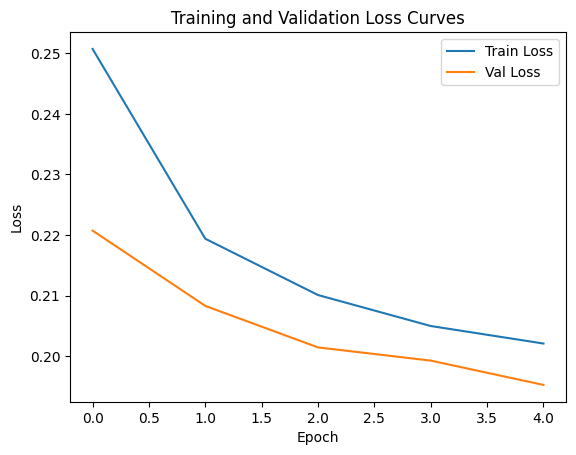

In [13]:
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.show()

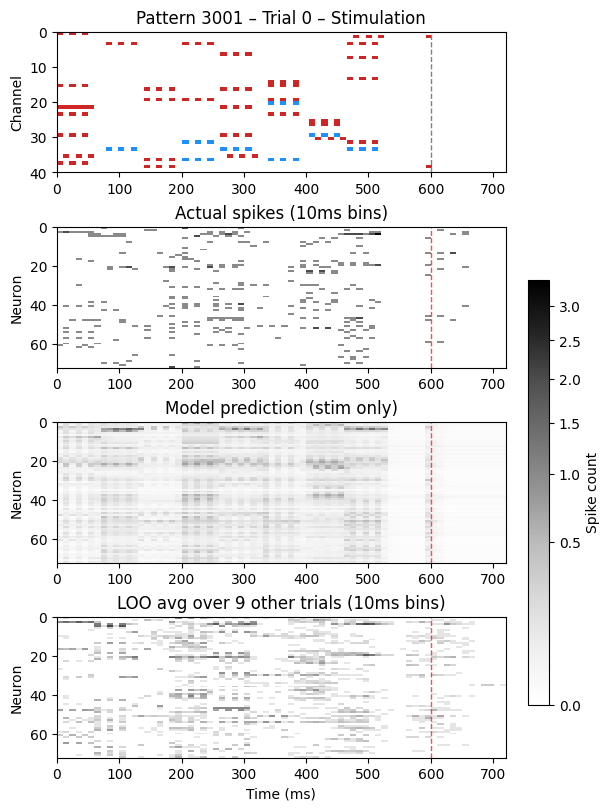

In [14]:
# ============================================================
# Visualize one trained CNN test example (oracle pattern), reusing
# patterns_5k/viz.py:plot_single_oracle_trial.
#
# Panels: stim polarity, actual spikes, model prediction, LOO trial average.
# ============================================================
import numpy as np
import torch
from viz import plot_single_oracle_trial

# Build the cfg + raw_data dicts the viz function expects.
cfg = dict(
    input_bin_size_ms  = CFG['INPUT_BIN_MS'],
    output_bin_size_ms = CFG['OUTPUT_BIN_MS'],
    n_input_bins       = CFG['N_INPUT_BINS'],
    n_output_bins      = CFG['N_OUTPUT_BINS'],
    max_time_ms        = CFG['MAX_TIME_MS'],
    output_offset      = 0,
    history            = 0,
    init_state         = False,
    encoding_mode      = CFG['ENCODING_MODE'],
)
raw_data = dict(
    pattern_df         = pattern_df,
    spike_responses    = spike_responses,
    pattern_polarities = pattern_polarities,
)
model_tuple = (model, base_criterion, device)

# Pick the first oracle pattern with at least 2 trials so LOO is meaningful.
unique_oracle = pattern_df[pattern_df['is_oracle']][['pattern_name', 'pattern_timing_index']].drop_duplicates()
counts = unique_oracle.groupby('pattern_name').size()
PATTERN_TO_SHOW = counts[counts >= 2].index[0] if (counts >= 2).any() else counts.index[0]
TRIAL_IDX = 0

fig = plot_single_oracle_trial(
    pattern_name=PATTERN_TO_SHOW,
    trial_idx=TRIAL_IDX,
    model_tuple=model_tuple,
    cfg=cfg,
    raw_data=raw_data,
    test_loader=test_loader,
    coarse_factor=1,
)

from IPython.display import display
fig.axes[2].set_title(f'Model prediction (stim only)')
display(fig)


### Stim creator

In [15]:
import heapq
import numpy as np
import torch


class StimCreator():
    """Greedy stim builder. Each 60 ms step (= 6 bins of 10 ms) can hold up to
    `budget_per_step` simultaneously-active channels; for each slot we try every
    (channel, encoding) candidate and keep the one whose model prediction has the
    smallest L2 distance to `target_spikes`.

    Hardware constraint enforced during the search: channels are partitioned
    into `n_shanks` equal-sized shanks by sorted channel ID, and at most
    `max_per_shank` channels per shank may fire SIMULTANEOUSLY (same bin within
    a step). Two channels with non-overlapping delay_mode bin-sets (e.g.
    dm=0 fires bins {0,2,4} vs dm=1 fires bins {1,3,5}) don't conflict.

    Encoding -> (offsets within the 6-bin step, amplitude) follows
    encode_pattern_nominal_current_10ms in patterns_5k/utils.py:
        delay_mode  0 -> bins {0,2,4}, +3
        delay_mode -1 -> bins {0,2,4}, -3
        delay_mode  1 -> bins {1,3,5}, +3
        delay_mode  2 -> bins {0..5},  +3
    """

    BINS_PER_STEP = 6  # 60 ms / 10 ms

    _ENCODING_TABLE = {
         0: ([0, 2, 4],            3), # 
        -1: ([0, 2, 4],           -3),
         1: ([1, 3, 5],           3),
         2: ([0, 1, 2, 3, 4, 5],   3),
    }

    def __init__(self, model, device, channel_to_index, n_bins,
                 n_shanks=4, max_per_shank=4, proj=None):
        self.model = model.to(device)
        self.model.eval()
        self.device = device
        self.channel_to_index = channel_to_index
        self.n_stim_channels = len(channel_to_index)
        self.n_bins = n_bins  # total 10 ms bins in the stim window

        # Shank partition: equal-sized chunks of sorted channel IDs.
        # Map ch_index (the row in the stim array) -> shank id.
        sorted_chs = sorted(channel_to_index.keys())
        if len(sorted_chs) % n_shanks != 0:
            raise ValueError(f"cannot split {len(sorted_chs)} channels into "
                             f"{n_shanks} equal shanks")
        shank_size = len(sorted_chs) // n_shanks
        ch_to_shank_by_id = {ch: i // shank_size
                             for i, ch in enumerate(sorted_chs)}
        # channel_to_index maps channel-id -> row in stim array; invert.
        self._idx_to_shank = np.empty(self.n_stim_channels, dtype=np.int64)
        for ch_id, idx in channel_to_index.items():
            self._idx_to_shank[idx] = ch_to_shank_by_id[ch_id]
        self.n_shanks = n_shanks
        self.max_per_shank = max_per_shank

        # Precompute bin-set per encoding.
        self._enc_bins = {enc: tuple(offsets)
                          for enc, (offsets, _amp) in self._ENCODING_TABLE.items()}
        
        # Projection for distance calculation: if provided, distance is measured in the projected space.
        if proj is not None:
            self.proj = proj
        else:
            self.proj = np.eye(n_neurons, dtype=np.float32)

    def stim_sequence_from_encoding(self, encoding):
        """Return a length-6 vector for one 60 ms step at 10 ms resolution."""
        seq = np.zeros(self.BINS_PER_STEP, dtype=np.float32)
        if encoding in self._ENCODING_TABLE:
            offsets, amp = self._ENCODING_TABLE[encoding]
            for o in offsets:
                seq[o] = amp
        return seq

    def _predict(self, stim, n_bins_truncate=None):
        """stim: (n_stim_channels, n_bins) -> (n_neurons, n_bins) numpy."""
        x = torch.from_numpy(stim).unsqueeze(0).to(self.device).float()
        with torch.no_grad():
            pred = self.model(x)
        if n_bins_truncate is not None:
            pred = pred[:, :, :n_bins_truncate]
        return torch.exp(pred).cpu().numpy()[0]

    def create_stim(self, target_spikes, budget_per_step=2,
                    encodings=(-1, 0, 1, 2), channels=None,
                    require_improvement=True, verbose=False):
        """Greedily build a stim driving the model toward `target_spikes`.

        Args:
            target_spikes: (n_neurons, n_bins) target.
            budget_per_step: max channels stimulated per 60 ms step.
            encodings: encoding labels to consider per slot.
            channels: stim-channel indices to consider (default: all).
            require_improvement: if True, stop filling a step's budget once no
                candidate strictly reduces distance.

        Returns:
            created_stim: (n_stim_channels, n_bins) float32.
            final_dist:   final L2 distance of model prediction to target.
        """
        if channels is None:
            channels = list(range(self.n_stim_channels))
        else:
            channels = list(channels)

        n_steps = self.n_bins // self.BINS_PER_STEP
        created_stim = np.zeros((self.n_stim_channels, self.n_bins), dtype=np.float32)
        used_channels_per_step = [set() for _ in range(n_steps)]
        # Per-step (shank, bin)-occupancy: shank_bin_count[step][shank, bin].
        shank_bin_count = [
            np.zeros((self.n_shanks, self.BINS_PER_STEP), dtype=np.int32)
            for _ in range(n_steps)
        ]
        curr_dist = np.linalg.norm(self._predict(created_stim, n_bins_truncate=self.n_bins).sum(axis=1) @ self.proj - target_spikes @ self.proj)
        if verbose:
            print(f"baseline dist: {curr_dist:.4f}")

        # Precompute encoding sequences.
        enc_seqs = [(e, self.stim_sequence_from_encoding(e)) for e in encodings]

        for step in range(n_steps):
            t0 = step * self.BINS_PER_STEP
            t1 = t0 + self.BINS_PER_STEP
            occ = shank_bin_count[step]

            for _ in range(budget_per_step):
                # Initialize best to the "add nothing this slot" option: the
                # distance of the stim as it currently stands (ch/enc/seq=None).
                # A real candidate is only chosen if it beats doing nothing.
                best = (curr_dist, None, None, None)  # (dist, ch, enc, seq)
                for ch in channels:
                    if ch in used_channels_per_step[step]:
                        continue
                    shank = self._idx_to_shank[ch]
                    for enc, seq in enc_seqs:
                        # Reject any candidate that would push a (shank, bin)
                        # cell above max_per_shank for this step.
                        bins_used = self._enc_bins[enc]
                        if any(occ[shank, b] + 1 > self.max_per_shank
                               for b in bins_used):
                            continue
                        cand = created_stim.copy()
                        cand[ch, t0:t1] = seq
                        d = np.linalg.norm(self._predict(cand, n_bins_truncate=self.n_bins).sum(axis=1) @ self.proj - target_spikes @ self.proj)
                        if d < best[0]: # greedy: must beat current best (incl. do-nothing)
                            best = (d, ch, enc, seq)

                # If the best option is to add nothing (no candidate beat the
                # do-nothing distance), stop filling this step's budget.
                if best[1] is None:
                    break
                if require_improvement and best[0] >= curr_dist:
                    break

                d, ch, enc, seq = best
                created_stim[ch, t0:t1] = seq
                used_channels_per_step[step].add(ch)
                # Commit the bin occupancy for the chosen channel/encoding.
                shank = self._idx_to_shank[ch]
                for b in self._enc_bins[enc]:
                    occ[shank, b] += 1
                curr_dist = d
                if verbose:
                    print(f"  step {step}: ch={ch}, enc={enc:>2}, dist={d:.4f}")

        return created_stim, curr_dist


In [16]:
VIS_ORIENT_TIME = 600  # ms window for visual orientation decoding (from above analysis)
BUDGET = 4  
targets = sum_responses[:, :, :VIS_ORIENT_TIME // 10].sum(axis=2)  # (n_orientations, n_neurons, n_bins) -> (n_orientations, n_neurons, 12) bc 10 ms bins
est_stims = []
distances = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    target_spikes = targets[o_idx]  # (n_neurons,)
    stim_creator = StimCreator(model, device, channel_to_index, n_bins=VIS_ORIENT_TIME // 10, proj=proj)
    created_stim, final_dist = stim_creator.create_stim(
        target_spikes=target_spikes,
        budget_per_step=BUDGET,
        encodings=[-1, 0, 1, 2],
        channels=None,
        require_improvement=True,
        verbose=True,
    )
    est_stims.append(created_stim)
    distances.append(final_dist)
    print(f"Orientation {orientation}°: final dist={final_dist:.4f}")


baseline dist: 30.0473
  step 0: ch=22, enc= 2, dist=25.1218
  step 0: ch=37, enc=-1, dist=22.3754
  step 0: ch=17, enc= 2, dist=21.2637
  step 0: ch=26, enc=-1, dist=20.3814
  step 1: ch=22, enc= 2, dist=15.5488
  step 1: ch=37, enc=-1, dist=13.4014
  step 1: ch=17, enc= 0, dist=12.9661
  step 1: ch=29, enc=-1, dist=12.4880
  step 2: ch=22, enc= 2, dist=8.4039
  step 2: ch=29, enc=-1, dist=7.6031
  step 3: ch=22, enc= 2, dist=6.4890
  step 3: ch=14, enc=-1, dist=6.2081
  step 3: ch=30, enc=-1, dist=6.1735
  step 3: ch=21, enc= 0, dist=6.0202
  step 4: ch=13, enc=-1, dist=5.9904
  step 4: ch=30, enc=-1, dist=5.9346
  step 4: ch=14, enc=-1, dist=5.8769
  step 4: ch=39, enc= 0, dist=5.8492
  step 5: ch=13, enc=-1, dist=5.7259
  step 6: ch=13, enc=-1, dist=5.6986
  step 7: ch=13, enc=-1, dist=5.6717
  step 8: ch=13, enc=-1, dist=5.6453
  step 9: ch=13, enc=-1, dist=5.6168
  step 9: ch=14, enc=-1, dist=5.6113
  step 9: ch=30, enc=-1, dist=5.5738
  step 9: ch=39, enc= 0, dist=5.5154
Orienta

(72, 60)


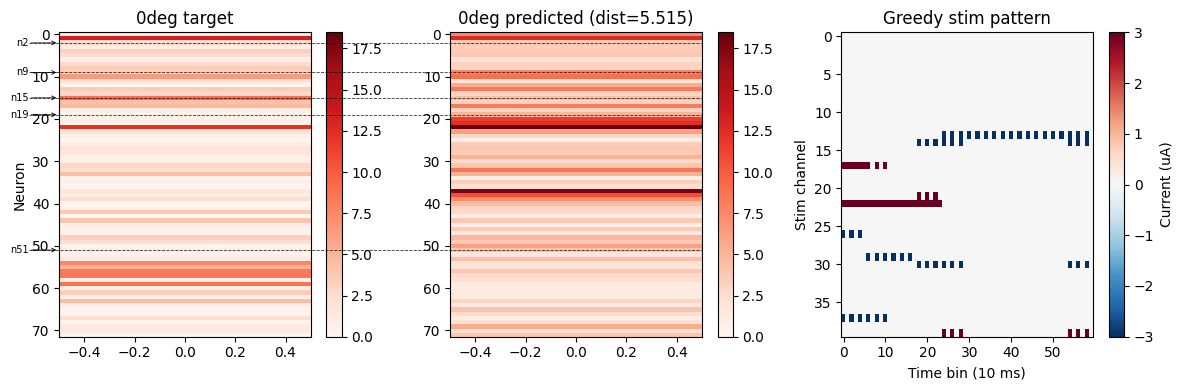

(72, 60)


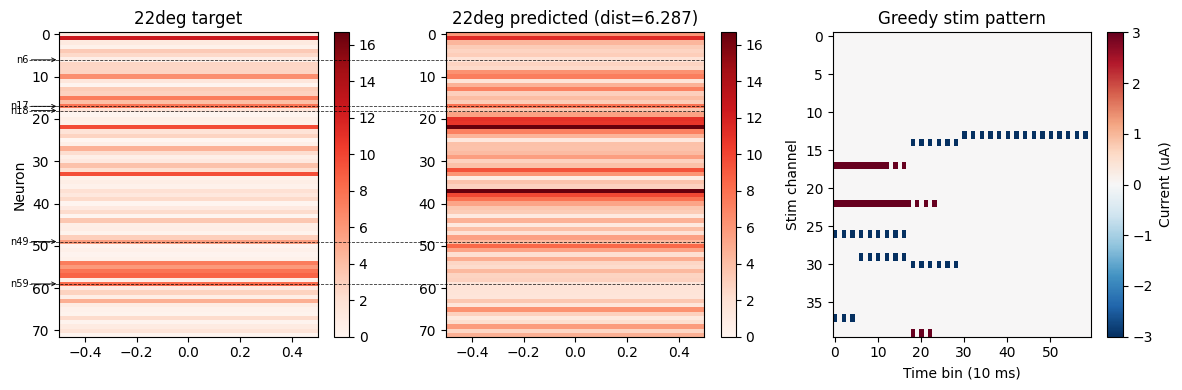

(72, 60)


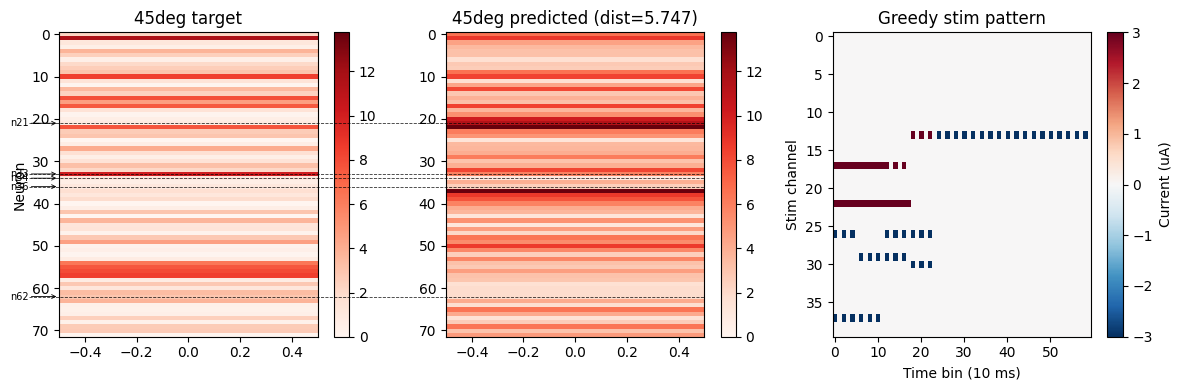

(72, 60)


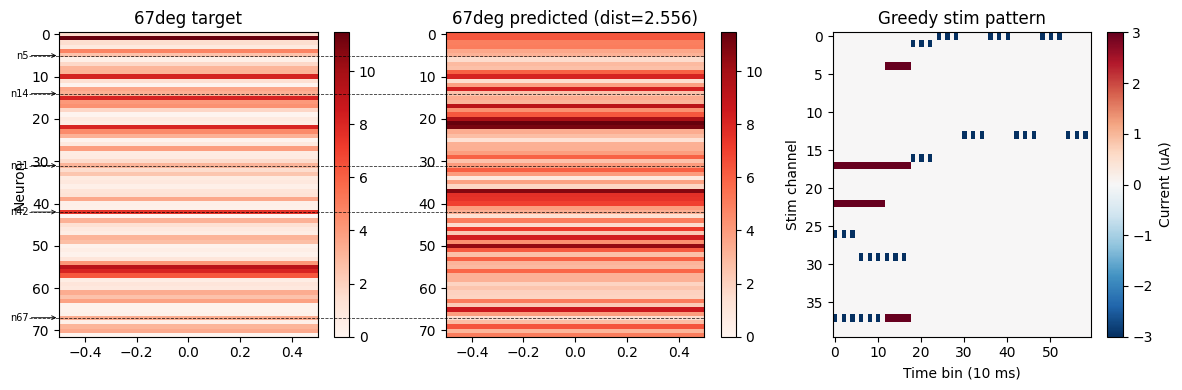

(72, 60)


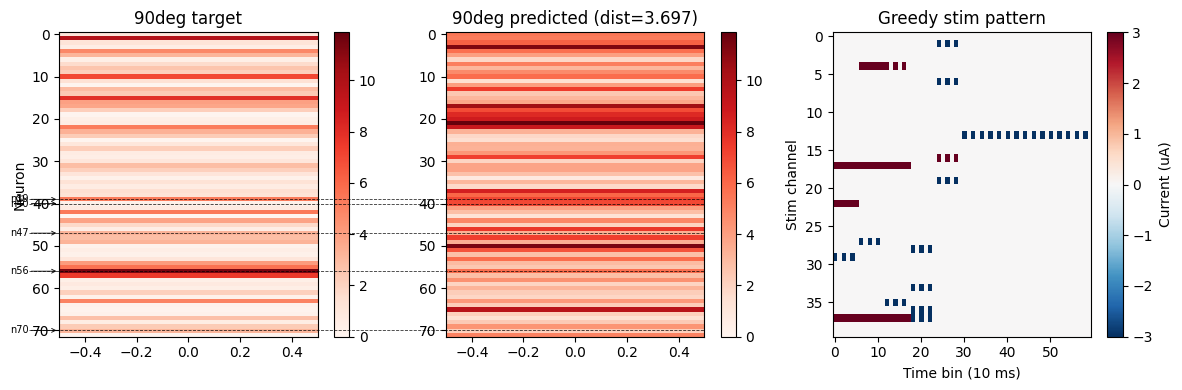

(72, 60)


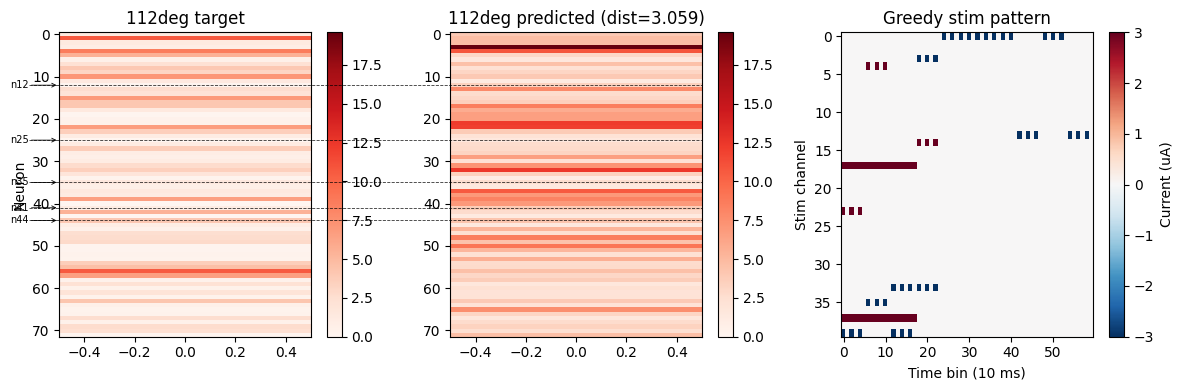

(72, 60)


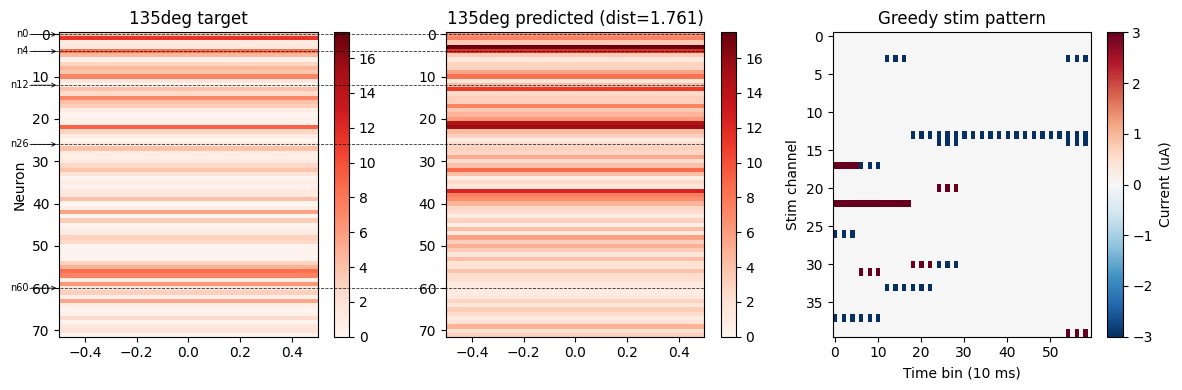

(72, 60)


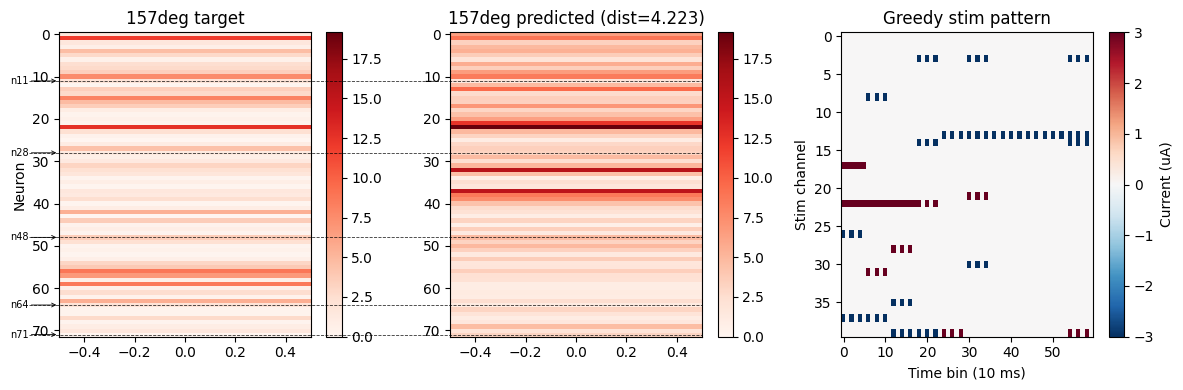

(72, 60)


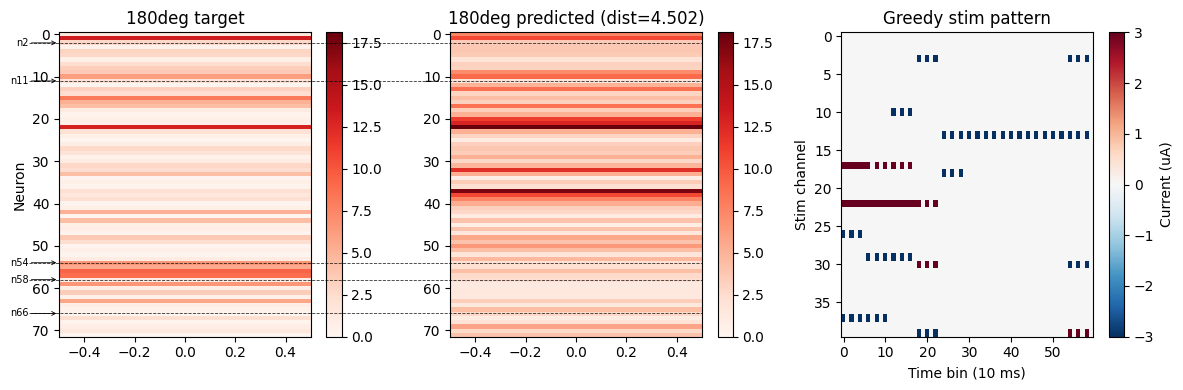

(72, 60)


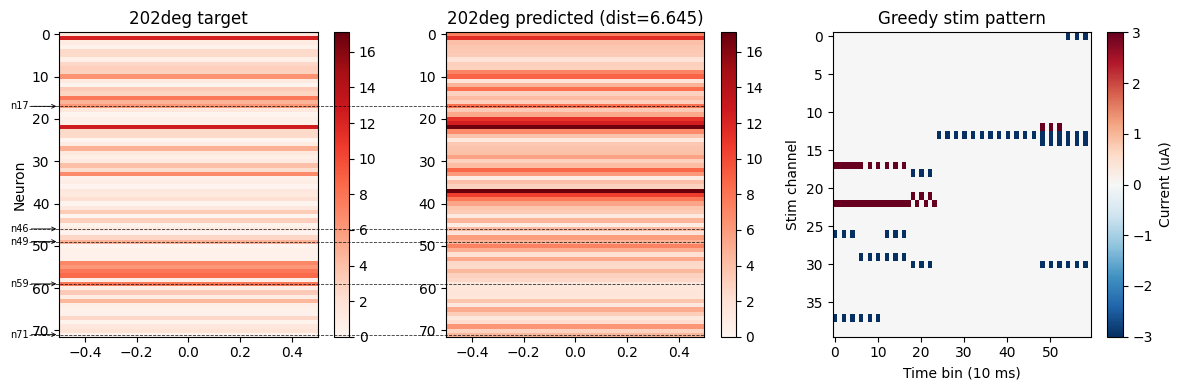

(72, 60)


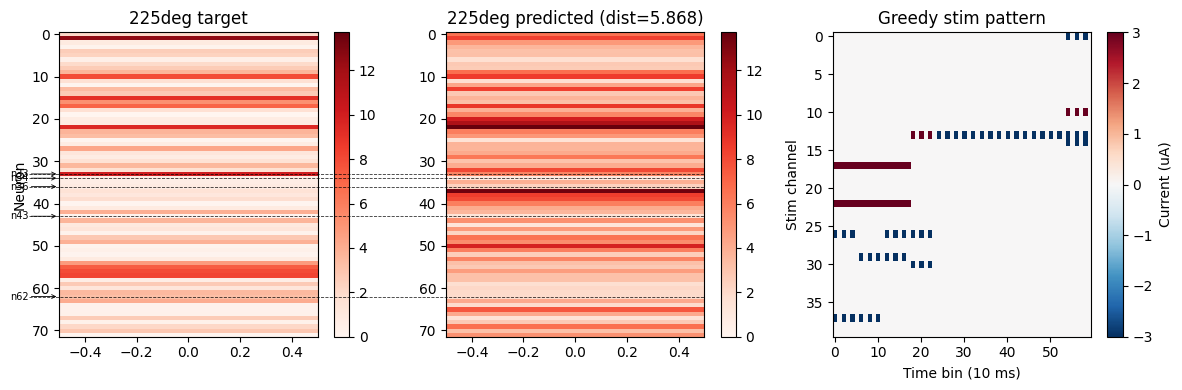

(72, 60)


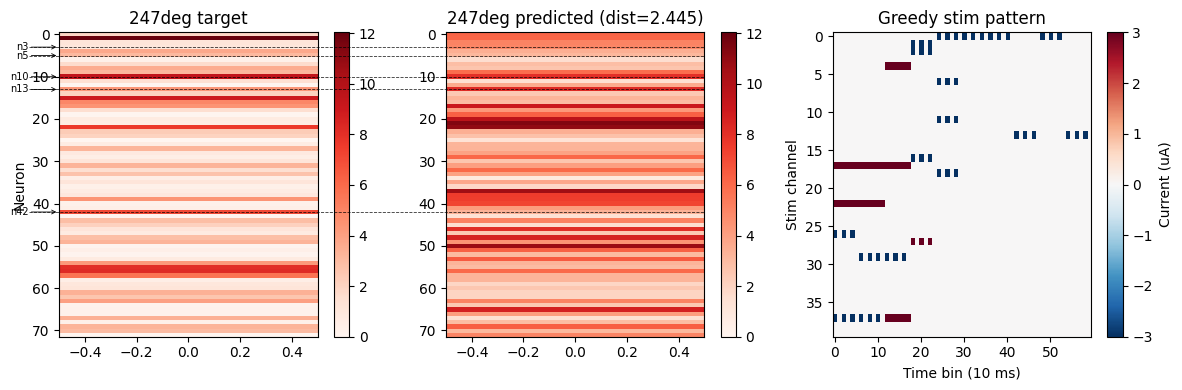

(72, 60)


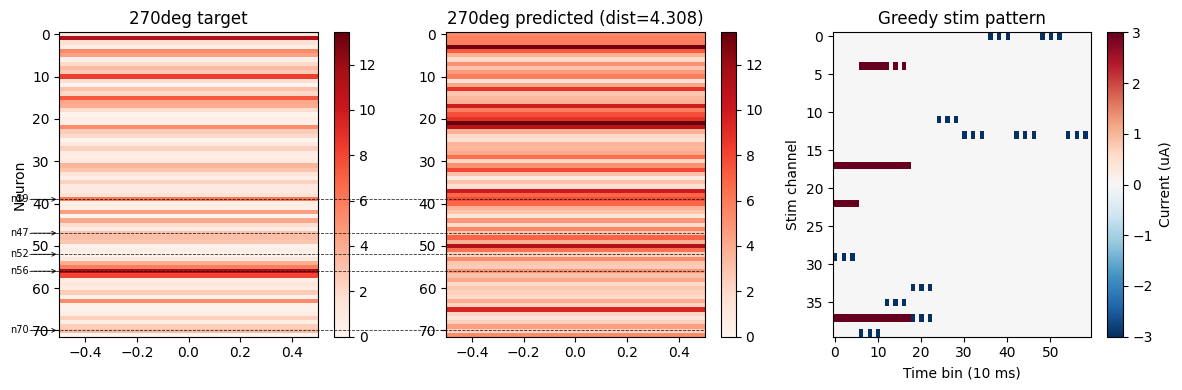

(72, 60)


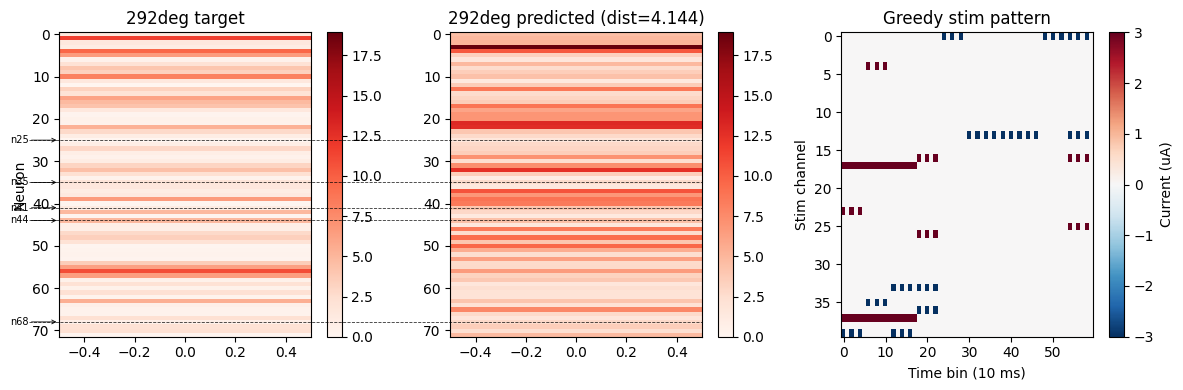

(72, 60)


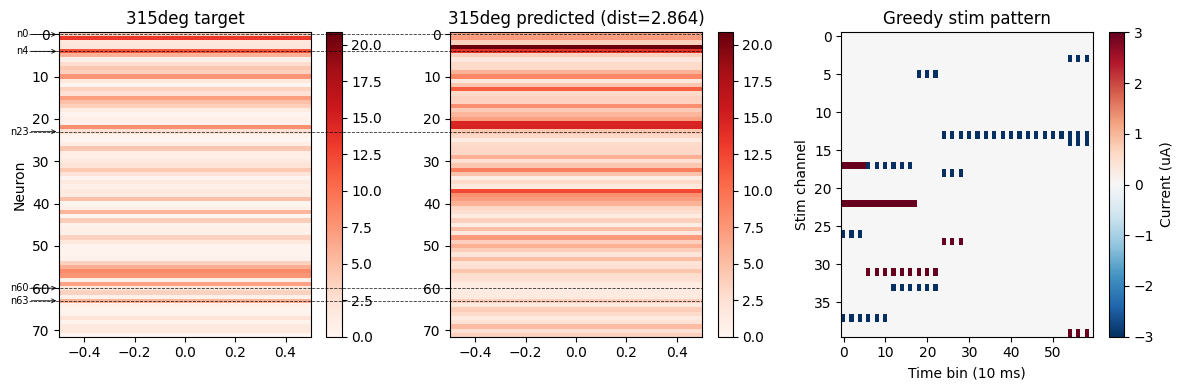

(72, 60)


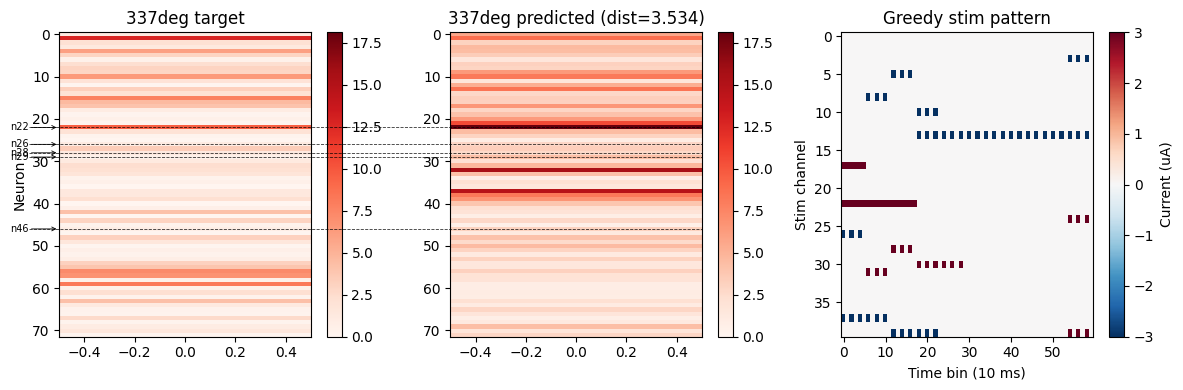

In [17]:
# Plot per orientation (3 horizontal imshow panels): target, predicted, stim.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.transforms import offset_copy

# Selectivity: per-(orient, neuron) z-score across orientations.
mu_n        = orient_total.mean(axis=0)
sigma_n     = orient_total.std(axis=0)
selectivity = (orient_total - mu_n) / (sigma_n + 1e-9)        # (n_orient, n_neurons)

ARROW_TEXT_OFFSET_PTS = -22  # matches xytext below

for o_idx, deg in enumerate(visual_orientation_degs):
    target_spikes = targets[o_idx]                  # (n_neurons,)
    created_stim  = est_stims[o_idx]                # (n_stim_channels, n_bins)

    x = torch.from_numpy(created_stim).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred = torch.exp(model(x)).cpu().numpy()[0]            # (n_neurons, n_bins)
    print (pred.shape)
    pred_counts = pred[:, :VIS_ORIENT_TIME // 10].sum(axis=1)                  # (n_neurons,) # truncated to same window as target

    f, ax = plt.subplots(1, 3, figsize=(12, 4))
    vmax = max(np.abs(target_spikes).max(), np.abs(pred_counts).max(), 1e-6)

    ax[0].imshow(target_spikes.reshape(-1, 1), aspect='auto', interpolation='nearest',
                 cmap='Reds', vmin=0, vmax=vmax)
    ax[0].set_title(f'{int(deg)}deg target')
    ax[0].set_ylabel('Neuron')
    plt.colorbar(ax[0].images[0], ax=ax[0])

    # Arrow ticks for the top-5 most positively selective neurons for this
    # orientation.
    top5 = np.argsort(selectivity[o_idx])[::-1][:5]
    for nidx in top5:
        ax[0].annotate(
            f'n{int(nidx)}',
            xy=(0, nidx), xycoords=('axes fraction', 'data'),
            xytext=(ARROW_TEXT_OFFSET_PTS, 0), textcoords='offset points',
            ha='right', va='center', fontsize=7, color='black',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.6,
                            shrinkA=0, shrinkB=2),
            annotation_clip=False,
        )

    ax[1].imshow(pred_counts.reshape(-1, 1), aspect='auto', interpolation='nearest',
                 cmap='Reds', vmin=0, vmax=vmax)
    ax[1].set_title(f'{int(deg)}deg predicted (dist={distances[o_idx]:.3f})')
    plt.colorbar(ax[1].images[0], ax=ax[1])

    amp_max = max(np.abs(created_stim).max(), 1)
    ax[2].imshow(created_stim, aspect='auto', interpolation='nearest',
                 cmap='RdBu_r', vmin=-amp_max, vmax=amp_max)
    ax[2].set_title('Greedy stim pattern')
    ax[2].set_xlabel('Time bin (10 ms)')
    ax[2].set_ylabel('Stim channel')
    plt.colorbar(ax[2].images[0], ax=ax[2], label='Current (uA)')

    plt.tight_layout()

    # Dashed lines from each arrow's tail (label position) across the first two
    # subplots, ending at the right edge of ax[1]'s axes box.
    f.canvas.draw()
    inv = f.transFigure.inverted()
    base = ax[0].get_yaxis_transform()  # ('axes fraction', 'data')
    tail_tf = offset_copy(base, fig=f, x=ARROW_TEXT_OFFSET_PTS, y=0, units='points')
    right_tf = ax[1].get_yaxis_transform()  # ('axes fraction', 'data') for ax[1]
    for nidx in top5:
        p_left  = inv.transform(tail_tf.transform((0, nidx)))
        p_right = inv.transform(right_tf.transform((1, nidx)))
        line = Line2D([p_left[0], p_right[0]], [p_left[1], p_right[1]],
                      transform=f.transFigure, color='black',
                      linestyle='--', linewidth=0.6, alpha=0.8, zorder=10)
        f.add_artist(line)

    plt.show()


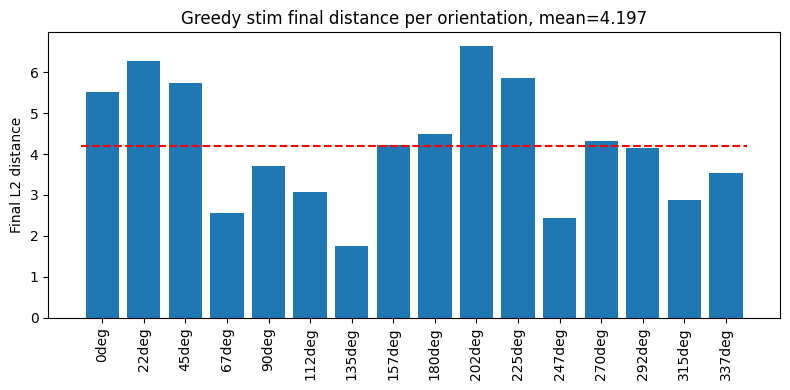

In [19]:
# Final L2 distance per orientation.
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(np.arange(len(visual_orientation_degs)), distances, color='C0')
ax.hlines(np.mean(distances), xmin=-0.5, xmax=len(visual_orientation_degs)-0.5, colors='red', linestyles='dashed', label='Mean')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_ylabel('Final L2 distance')
ax.set_title('Greedy stim final distance per orientation, mean={:.3f}'.format(np.mean(distances)))
plt.tight_layout()
plt.show()


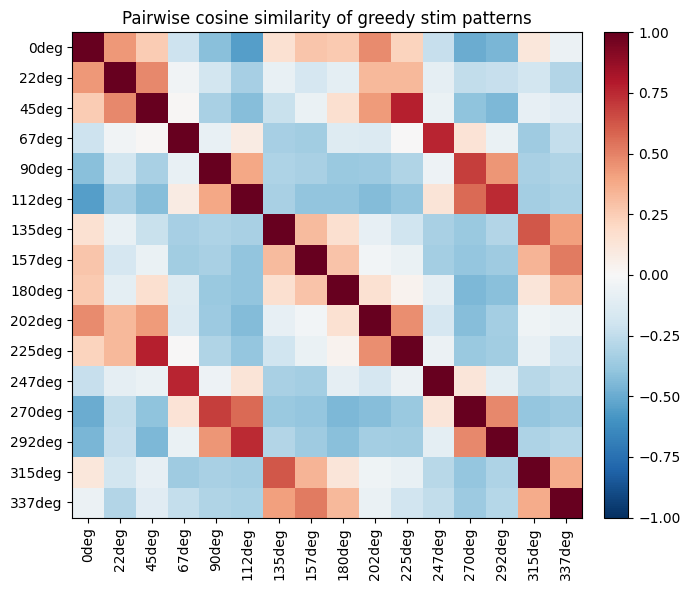

unique stim patterns (exact): 16 / 16
exact-match pairs: 0
mean off-diagonal cosine sim: -0.060


In [20]:
# Pairwise cosine similarity of greedy stim patterns across orientations.
from sklearn.preprocessing import normalize
import numpy as np 
stim_flat = np.stack([s.flatten() for s in est_stims], axis=0)  # (n_orient, n_ch * n_bins)
stim_flat = stim_flat - stim_flat.mean(axis=0, keepdims=True)  # zero-center for cosine similarity
stim_normed = normalize(stim_flat, norm='l2')
sim_stim = stim_normed @ stim_normed.T  # (n_orient, n_orient)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_stim, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
ax.set_title('Pairwise cosine similarity of greedy stim patterns')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Quick uniqueness summary.
n_orient = len(est_stims)
exact_matches = sum(
    1 for i in range(n_orient) for j in range(i + 1, n_orient)
    if np.array_equal(est_stims[i], est_stims[j])
)

unique_count = len({s.tobytes() for s in est_stims})
print(f'unique stim patterns (exact): {unique_count} / {n_orient}')
print(f'exact-match pairs: {exact_matches}')
print(f'mean off-diagonal cosine sim: {sim_stim[np.triu_indices(n_orient, k=1)].mean():.3f}')


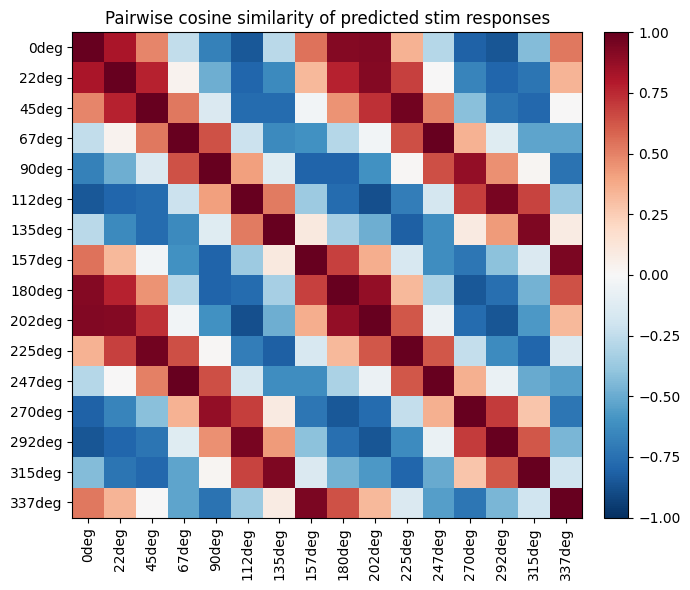

In [21]:
# cosine similarity of predicted stim response vectors 
pred_responses = []
for created_stim in est_stims:
    x = torch.from_numpy(created_stim).unsqueeze(0).to(device).float()
    with torch.no_grad():
        pred = torch.exp(model(x)).cpu().numpy()[0]            # (n_neurons, n_bins)
    pred_counts = pred[:, :VIS_ORIENT_TIME // 10].sum(axis=1)                  # (n_neurons,)
    pred_responses.append(pred_counts)
pred_responses = np.stack(pred_responses, axis=0)   # (n_orient, n_neurons)
pred_responses_normed = normalize(pred_responses - np.mean(pred_responses, axis=0), norm='l2')
sim_pred_resp = pred_responses_normed @ pred_responses_normed.T  # (n_orient, n_orient) 
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_pred_resp, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
ax.set_title('Pairwise cosine similarity of predicted stim responses')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04        )
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Pairwise cosine similarity of actual target responses 600 ms')

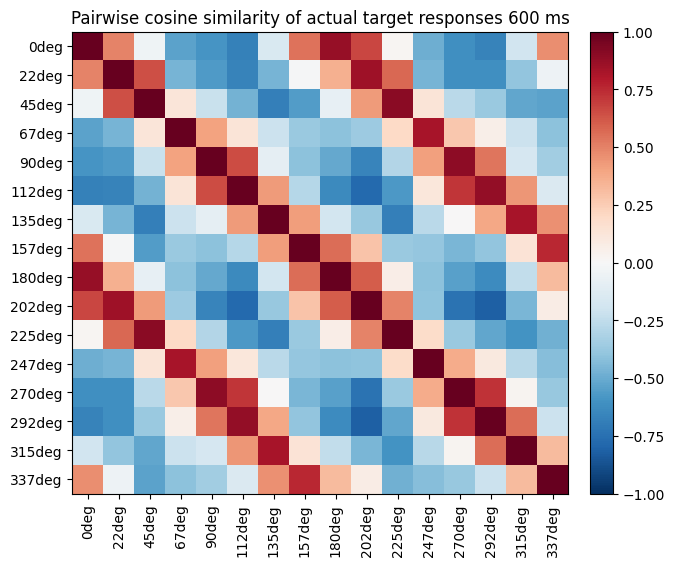

In [22]:
# pairwise cosine similarity of target response vectors (for reference)
targets_normed = normalize(targets - np.mean(targets, axis=0), norm='l2')
sim_target_resp = targets_normed @ targets_normed.T  # (n_orient, n_orient) 
fig, ax = plt.subplots(figsize=(7, 6))          
im = ax.imshow(sim_target_resp, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(visual_orientation_degs)))
ax.set_yticks(range(len(visual_orientation_degs)))
ax.set_xticklabels([f'{int(d)}deg' for d in visual_orientation_degs], rotation=90)
ax.set_yticklabels([f'{int(d)}deg' for d in visual_orientation_degs])
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04        )
ax.set_title(f'Pairwise cosine similarity of actual target responses {VIS_ORIENT_TIME} ms')          

In [23]:
# Project everything (observed averages, per-trial dots, CNN predictions) into a
# shared (CIS, PC1, PC2) space built from the SAME VIS_ORIENT_TIME window used
# to define the targets, so all three live on a common scale.
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Rebuild the projection from `targets` (== sum_responses windowed to VIS_ORIENT_TIME).
X_win        = targets                                      # (n_orient, n_neurons)
mean_vec_win = X_win.mean(axis=0, keepdims=True)
pca_win      = PCA(n_components=2).fit(X_win)
proj_win, _  = np.linalg.qr(np.array([
    mean_vec_win[0],
    pca_win.components_[0],
    pca_win.components_[1],
]).T)                                                       # (n_neurons, 3)
coords_win   = X_win @ proj_win                             # (n_orient, 3)

# CNN predictions under greedy stims (already over the VIS_ORIENT_TIME window).
greedy_pred_full = np.zeros((len(visual_orientation_degs), n_neurons), dtype=np.float32)
for o_idx in range(len(visual_orientation_degs)):
    x = torch.from_numpy(est_stims[o_idx]).unsqueeze(0).to(device).float()
    with torch.no_grad():
        rate = torch.exp(model(x))                          # (1, n_neurons, n_bins)
    greedy_pred_full[o_idx] = rate[0, :, :VIS_ORIENT_TIME // 10].sum(dim=1).cpu().numpy()
greedy_coords_win = greedy_pred_full @ proj_win

# Per-trial dots over the same VIS_ORIENT_TIME window.
vis_window_samples = (VIS_ORIENT_TIME * SAMPLE_RATE) // 1000
trial_coords  = []
trial_doubled = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + vis_window_samples)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj_win)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords  = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=trial_coords[:, 0], y=trial_coords[:, 1], z=trial_coords[:, 2],
    mode='markers',
    marker=dict(size=3, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.1, line=dict(width=0)),
    name='Per-trial', hoverinfo='skip',
))
fig.add_trace(go.Scatter3d(
    x=coords_win[:, 0], y=coords_win[:, 1], z=coords_win[:, 2],
    mode='markers+text',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                line=dict(color='black', width=1),
                colorbar=dict(title='Orientation (deg)')),
    text=[f'{int(o)}deg' for o in visual_orientation_degs],
    textposition='top center',
    name='Observed orientation avg',
))
fig.add_trace(go.Scatter3d(
    x=greedy_coords_win[:, 0], y=greedy_coords_win[:, 1], z=greedy_coords_win[:, 2],
    mode='markers',
    marker=dict(size=8, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                symbol='diamond', line=dict(color='white', width=1)),
    name='Greedy stim CNN prediction',
))
for o in range(len(visual_orientation_degs)):
    fig.add_trace(go.Scatter3d(
        x=[coords_win[o, 0], greedy_coords_win[o, 0]],
        y=[coords_win[o, 1], greedy_coords_win[o, 1]],
        z=[coords_win[o, 2], greedy_coords_win[o, 2]],
        mode='lines', line=dict(color='gray', width=2, dash='dot'),
        showlegend=(o == 0), name='match link', hoverinfo='skip',
    ))

fig.update_layout(
    title=f'Observed vs CNN-predicted responses (all over {VIS_ORIENT_TIME} ms window)',
    scene=dict(xaxis_title='CIS', yaxis_title='PC1', zaxis_title='PC2',
               aspectmode='data'),
    width=850, height=700,
)
fig.show()


In [24]:
# Project observed averages, per-trial dots, and CNN predictions into PC1/PC2,
# computed from the same VIS_ORIENT_TIME window used to define the targets.
import os
import plotly.graph_objects as go
from sklearn.decomposition import PCA

X_win  = targets                                # (n_orient, n_neurons)
pca_win = PCA(n_components=2).fit(X_win)
proj_win = pca_win.components_.T                # (n_neurons, 2)
coords_win = X_win @ proj_win                   # (n_orient, 2)

# CNN predictions under greedy stims (already over the VIS_ORIENT_TIME window).
greedy_pred_full = np.zeros((len(visual_orientation_degs), n_neurons), dtype=np.float32)
for o_idx in range(len(visual_orientation_degs)):
    x = torch.from_numpy(est_stims[o_idx]).unsqueeze(0).to(device).float()
    with torch.no_grad():
        rate = torch.exp(model(x))              # (1, n_neurons, n_bins)
    greedy_pred_full[o_idx] = rate[0, :, :VIS_ORIENT_TIME // 10].sum(dim=1).cpu().numpy()
greedy_coords_win = greedy_pred_full @ proj_win

# Per-trial dots over the same VIS_ORIENT_TIME window.
vis_window_samples = (VIS_ORIENT_TIME * SAMPLE_RATE) // 1000
trial_coords  = []
trial_doubled = []
for o_idx, orientation in enumerate(visual_orientation_degs):
    trial_times = visual_trial_df[visual_trial_df['orientation'] == orientation]['timestamp'].values[:N_VIS_TRIALS]
    for t_time in trial_times:
        trial_spikes = visual_spikes[(visual_spikes['timestamp'] >= t_time) &
                                     (visual_spikes['timestamp'] <  t_time + vis_window_samples)]
        x_trial = np.zeros(n_neurons)
        if not trial_spikes.empty:
            counts = trial_spikes.groupby('neuron_id').size()
            for nid, c in counts.items():
                if nid in neuron_to_idx:
                    x_trial[neuron_to_idx[nid]] = c
        trial_coords.append(x_trial @ proj_win)
        trial_doubled.append((int(orientation) * 2) % 360)
trial_coords  = np.array(trial_coords)
trial_doubled = np.array(trial_doubled)

doubled = (np.array(visual_orientation_degs) * 2) % 360

fig = go.Figure()

# Per-trial cloud
fig.add_trace(go.Scatter(
    x=trial_coords[:, 0], y=trial_coords[:, 1],
    mode='markers',
    marker=dict(size=5, color=trial_doubled, colorscale='HSV',
                cmin=0, cmax=360, opacity=0.1, line=dict(width=0)),
    hoverinfo='skip', showlegend=False,
))

# Match links between observed and predicted
for o in range(len(visual_orientation_degs)):
    fig.add_trace(go.Scatter(
        x=[coords_win[o, 0], greedy_coords_win[o, 0]],
        y=[coords_win[o, 1], greedy_coords_win[o, 1]],
        mode='lines', line=dict(color='gray', width=1, dash='dot'),
        hoverinfo='skip', showlegend=False,
    ))

# Observed orientation averages (circles)
fig.add_trace(go.Scatter(
    x=coords_win[:, 0], y=coords_win[:, 1],
    mode='markers',
    marker=dict(size=10, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                line=dict(color='black', width=1),
                colorbar=dict(
                    title='Orientation (°)',
                    tickvals=np.arange(0, 361, 72),
                    ticktext=[f'{int(v/2)}°' for v in np.arange(0, 361, 72)],
                )),
    showlegend=False,
))

# Greedy CNN predictions (diamonds)
fig.add_trace(go.Scatter(
    x=greedy_coords_win[:, 0], y=greedy_coords_win[:, 1],
    mode='markers',
    marker=dict(size=10, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                symbol='diamond', line=dict(color='white', width=1)),
    showlegend=False,
))

fig.update_layout(
    title=f'Observed vs CNN-predicted responses ({VIS_ORIENT_TIME} ms window)',
    xaxis_title='PC1', yaxis_title='PC2',
    width=850, height=700,
)

os.makedirs('results', exist_ok=True)
fig.write_html('results/vis_response_pc1_pc2_recon.html', include_plotlyjs='cdn')
try:
    fig.write_image('results/vis_response_pc1_pc2_recon.svg', width=850, height=700, scale=2)
    fig.write_image('results/vis_response_pc1_pc2_recon.pdf', width=850, height=700, scale=2)
except Exception as e:
    print(f'[image export skipped: {e}]')
    print('Open the HTML in a browser and File > Print > Save as PDF for vector output.')
fig.show()


In [25]:
# Oracle test patterns in the same PC space as cell 22.
# True per-pattern average -> CNN prediction shown as a gray arrow.
# Patterns closest to a visual orientation target are drawn bolder.
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA

mode = "2d"

n_out_window_bins = VIS_ORIENT_TIME // CFG['OUTPUT_BIN_MS']

# Rebuild the basis from `targets` so this cell is self-contained.
X_win        = targets
mean_vec_win = X_win.mean(axis=0, keepdims=True)
pca_win3     = PCA(n_components=2).fit(X_win)
if mode == "3d":
    proj, _ = np.linalg.qr(np.array([
        mean_vec_win[0],
        pca_win3.components_[0],
        pca_win3.components_[1],
    ]).T)
else:
    proj = pca_win3.components_.T[:, :2]                                        # (n_neurons, 2)
coords_win = X_win @ proj                                                       # (n_orient, 2 or 3)

# Group oracle test trials by pattern_name.
pattern_to_timings = {}
for timing_idx in test_ds.trial_indices:
    pname = test_ds.timing_to_pattern[timing_idx]
    pattern_to_timings.setdefault(pname, []).append(timing_idx)
oracle_patterns = sorted(pattern_to_timings.keys())
n_patterns = len(oracle_patterns)

# True per-pattern average and per-trial points over the window.
true_avg_counts = np.zeros((n_patterns, n_neurons), dtype=np.float32)
trial_true_pts  = []
trial_pidx      = []
for p_idx, pname in enumerate(oracle_patterns):
    timings = pattern_to_timings[pname]
    trial_counts = np.zeros((len(timings), n_neurons), dtype=np.float32)
    for k, tidx in enumerate(timings):
        binned = test_ds.spike_responses_binned[tidx]
        trial_counts[k] = binned[:, :n_out_window_bins].sum(axis=1)
        trial_true_pts.append(trial_counts[k])
        trial_pidx.append(p_idx)
    true_avg_counts[p_idx] = trial_counts.mean(axis=0)
trial_true_pts = np.array(trial_true_pts)
trial_pidx     = np.array(trial_pidx)

# Model prediction per unique oracle pattern, summed over the same window.
pred_counts = np.zeros((n_patterns, n_neurons), dtype=np.float32)
model.eval()
for p_idx, pname in enumerate(oracle_patterns):
    stim    = test_ds.pattern_stims[pname]
    stim_in = stim[:, :CFG['N_INPUT_BINS']]
    x = torch.from_numpy(stim_in).unsqueeze(0).to(device).float()
    with torch.no_grad():
        rate = torch.exp(model(x))
    pred_counts[p_idx] = rate[0, :, :n_out_window_bins].sum(dim=1).cpu().numpy()

# Project onto the chosen basis.
true_coords       = true_avg_counts @ proj
pred_coords       = pred_counts     @ proj
trial_true_coords = trial_true_pts  @ proj
trial_pred_coords = pred_coords[trial_pidx]

# Per-orientation target projections (used for the closest-pattern lookup and
# the min/max-diameter dashed lines below).
proj_targs = np.stack([targets[i] @ proj for i in range(len(visual_orientation_degs))],
                      axis=0)

# For each visual orientation, find the oracle pattern whose true-response
# projection is nearest. Build the deduped list (orientation order) and a
# set of bold pattern indices.
closest_pattern_idxs = []
for ori_idx in range(len(visual_orientation_degs)):
    dists = np.linalg.norm(true_coords - proj_targs[ori_idx], axis=1)
    closest_pattern_idxs.append(int(np.argmin(dists)))

bold_idxs = set(closest_pattern_idxs)
seen = set()
closest_patterns = []
for p_idx in closest_pattern_idxs:
    pname = oracle_patterns[p_idx]
    if pname not in seen:
        closest_patterns.append(pname)
        seen.add(pname)

# One color per pattern, shared across arrow + trial dots.
viridis = px.colors.sample_colorscale('Viridis',
                                      np.linspace(0, 1, max(n_patterns, 2)).tolist())
trial_colors = [viridis[i] for i in trial_pidx]

fig = go.Figure()

# Per-trial faded prediction points.
if mode == "3d":
    fig.add_trace(go.Scatter3d(
        x=trial_pred_coords[:, 0], y=trial_pred_coords[:, 1], z=trial_pred_coords[:, 2],
        mode='markers',
        marker=dict(size=3, color=trial_colors, opacity=0.2,
                    symbol='diamond', line=dict(width=0)),
        name='Pred per-trial', hoverinfo='skip',
    ))
else:
    fig.add_trace(go.Scatter(
        x=trial_pred_coords[:, 0], y=trial_pred_coords[:, 1],
        mode='markers',
        marker=dict(size=5, color=trial_colors, opacity=0.2,
                    symbol='diamond', line=dict(width=0)),
        name='Pred per-trial', hoverinfo='skip',
    ))

# Arrows from true average -> prediction. Patterns nearest to a visual
# orientation target are drawn with a thicker line + larger arrowhead.
for p_idx in range(n_patterns):
    is_bold    = p_idx in bold_idxs
    color      = "black" if is_bold else "gray"
    line_width = 4 if is_bold else 2
    head_size  = 16 if is_bold else 10
    cone_size  = 0.8 if is_bold else 0.5
    a = true_coords[p_idx]
    b = pred_coords[p_idx]
    if mode == "3d":
        fig.add_trace(go.Scatter3d(
            x=[a[0], b[0]], y=[a[1], b[1]], z=[a[2], b[2]],
            mode='lines',
            line=dict(color=color, width=line_width),
            showlegend=False, hoverinfo='skip',
        ))
        fig.add_trace(go.Cone(
            x=[b[0]], y=[b[1]], z=[b[2]],
            u=[b[0] - a[0]], v=[b[1] - a[1]], w=[b[2] - a[2]],
            sizemode='absolute', sizeref=cone_size, anchor='tip',
            colorscale=[[0, color], [1, color]], showscale=False,
            hoverinfo='skip',
        ))
    else:
        fig.add_trace(go.Scatter(
            x=[a[0], b[0]], y=[a[1], b[1]],
            mode='lines+markers',
            line=dict(color=color, width=line_width),
            marker=dict(size=[0, head_size], symbol='arrow-up', color=color,
                        angleref='previous'),
            showlegend=False, hoverinfo='skip',
        ))

# Visual-orientation ring as faint backdrop (HSV color, doubled angle).
if mode == "3d":
    fig.add_trace(go.Scatter3d(
        x=coords_win[:, 0], y=coords_win[:, 1], z=coords_win[:, 2],
        mode='markers',
        marker=dict(size=6, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                    opacity=0.35, line=dict(color='black', width=1)),
        name='Visual orient avg (ref)', hoverinfo='skip',
    ))
else:
    fig.add_trace(go.Scatter(
        x=coords_win[:, 0], y=coords_win[:, 1],
        mode='markers',
        marker=dict(size=6, color=doubled, colorscale='HSV', cmin=0, cmax=360,
                    opacity=0.35, line=dict(color='black', width=1)),
        name='Visual orient avg (ref)', hoverinfo='skip',
    ))

# Min/max diameter dashed lines from 90 deg pairs.
dist_matrix = np.linalg.norm(proj_targs[:, None, :] - proj_targs[None, :, :], axis=-1)
quarter = len(visual_orientation_degs) // 4
n_unique_pairs = len(visual_orientation_degs) // 2
pair_distances = [dist_matrix[i, (i + quarter) % len(visual_orientation_degs)]
                  for i in range(n_unique_pairs)]

min_radius = min(pair_distances) / 2
max_radius = max(pair_distances) / 2
max_i = int(np.argmax(pair_distances))
min_i = int(np.argmin(pair_distances))
max_pair = (max_i, (max_i + quarter) % len(visual_orientation_degs))
min_pair = (min_i, (min_i + quarter) % len(visual_orientation_degs))

if mode == "3d":
    fig.add_trace(go.Scatter3d(
        x=[proj_targs[max_pair[0], 0], proj_targs[max_pair[1], 0]],
        y=[proj_targs[max_pair[0], 1], proj_targs[max_pair[1], 1]],
        z=[proj_targs[max_pair[0], 2], proj_targs[max_pair[1], 2]],
        mode='lines',
        line=dict(color='red', width=3, dash='dash'),
        name=f'Max 90 deg pair ({pair_distances[max_i]:.2f})',
    ))
    fig.add_trace(go.Scatter3d(
        x=[proj_targs[min_pair[0], 0], proj_targs[min_pair[1], 0]],
        y=[proj_targs[min_pair[0], 1], proj_targs[min_pair[1], 1]],
        z=[proj_targs[min_pair[0], 2], proj_targs[min_pair[1], 2]],
        mode='lines',
        line=dict(color='blue', width=3, dash='dash'),
        name=f'Min 90 deg pair ({pair_distances[min_i]:.2f})',
    ))
else:
    fig.add_trace(go.Scatter(
        x=[proj_targs[max_pair[0], 0], proj_targs[max_pair[1], 0]],
        y=[proj_targs[max_pair[0], 1], proj_targs[max_pair[1], 1]],
        mode='lines',
        line=dict(color='red', width=3, dash='dash'),
        name=f'Max 90 deg pair ({pair_distances[max_i]:.2f})',
    ))
    fig.add_trace(go.Scatter(
        x=[proj_targs[min_pair[0], 0], proj_targs[min_pair[1], 0]],
        y=[proj_targs[min_pair[0], 1], proj_targs[min_pair[1], 1]],
        mode='lines',
        line=dict(color='blue', width=3, dash='dash'),
        name=f'Min 90 deg pair ({pair_distances[min_i]:.2f})',
    ))

layout_kwargs = dict(
    title=f'Oracle test patterns: true -> CNN prediction ({VIS_ORIENT_TIME} ms)',
    width=950, height=800,
)
if mode == "3d":
    layout_kwargs['scene'] = dict(xaxis_title='CIS', yaxis_title='PC1',
                                  zaxis_title='PC2', aspectmode='data')
else:
    layout_kwargs['xaxis_title'] = 'PC1'
    layout_kwargs['yaxis_title'] = 'PC2'
    layout_kwargs['yaxis'] = dict(scaleanchor='x', scaleratio=1)
fig.update_layout(**layout_kwargs)

os.makedirs('results', exist_ok=True)
fig.write_html('results/oracle_pred_vs_true_cis_pc1_pc2.html', include_plotlyjs='cdn')

l2_per_pattern = np.linalg.norm(true_coords - pred_coords, axis=1)

print(f'Oracle patterns: {n_patterns}  '
      f'mean L2 (true vs pred, projected): {l2_per_pattern.mean():.3f} '
      f'+- {l2_per_pattern.std():.3f}')
print(f'Closest patterns to visual orientations: {closest_patterns}')

fig.show()


Oracle patterns: 100  mean L2 (true vs pred, projected): 2.233 +- 1.139
Closest patterns to visual orientations: [3076, 3088, 3028, 3094, 3051, 3050, 3038, 3098]


In [28]:
# ============================================================
# Build pattern registrations directly from est_stims (16 unique patterns,
# 2 steps of 60 ms each). For each step, decode the 6-bin slice on each
# channel into a (channel, delay_mode) entry -- no redistribution.
#
# Hardware constraint: channels are partitioned into 4 equal-sized shanks
# by sorted channel ID, and at most MAX_PER_SHANK channels per shank may
# fire SIMULTANEOUSLY (same bin within a step). Channels with non-overlapping
# delay_mode bin-sets (e.g. dm=0 fires bins {0,2,4} vs dm=1 fires bins {1,3,5})
# don't conflict and may share a shank. Offending channels are flagged and
# dropped to make every (shank, bin) <= MAX_PER_SHANK.
# ============================================================
import pickle
import copy
import itertools
from collections import Counter

K_TRIALS = 1
SHUFFLE_SEED = 0
BINS_PER_STEP = StimCreator.BINS_PER_STEP
STEP_MS = 60
n_bins = est_stims[0].shape[1]
n_steps = n_bins // BINS_PER_STEP
index_to_channel = {idx: ch for ch, idx in channel_to_index.items()}

# ---- Shank partition: 4 equal-sized shanks by sorted channel ID ----
MAX_PER_SHANK = 4
N_SHANKS = 4


sorted_channels = sorted(channel_to_index.keys())
assert len(sorted_channels) % N_SHANKS == 0, (
    f'cannot split {len(sorted_channels)} channels into {N_SHANKS} equal shanks')
shank_size = len(sorted_channels) // N_SHANKS
channel_to_shank = {ch: i // shank_size for i, ch in enumerate(sorted_channels)}
print(f'shanks: {N_SHANKS} x {shank_size} channels  '
      f'(max {MAX_PER_SHANK} simultaneous per shank per bin)')

def slice_to_delay_mode(slice6):
    if not np.any(slice6):
        return None
    for dm, (offsets, amp) in StimCreator._ENCODING_TABLE.items():
        target = np.zeros(BINS_PER_STEP, dtype=np.float32)
        for o in offsets:
            target[o] = amp
        if np.array_equal(slice6, target):
            return dm
    return None

# bin-set per delay_mode -- two channels collide only if these intersect.
DM_BINS = {dm: set(offsets) for dm, (offsets, _amp) in StimCreator._ENCODING_TABLE.items()}

def enforce_shank_limit(cds, ori_idx, step_idx):
    """At most MAX_PER_SHANK channels firing per (shank, bin).

    Walks channels in ascending order; drops a channel if adding it would
    push any (shank, bin) count above the limit. Flags every drop.
    """
    live = {}  # shank -> {bin_idx: count}
    kept, dropped_log = [], []
    for cd in cds:
        shank = channel_to_shank[cd['channel']]
        bins_used = DM_BINS[cd['delay_mode']]
        shank_counts = live.setdefault(shank, {})
        if any(shank_counts.get(b, 0) + 1 > MAX_PER_SHANK for b in bins_used):
            dropped_log.append((shank, cd['channel'], cd['delay_mode']))
            continue
        for b in bins_used:
            shank_counts[b] = shank_counts.get(b, 0) + 1
        kept.append(cd)
    if dropped_log:
        by_shank_drop = {}
        for shank, ch, dm in dropped_log:
            by_shank_drop.setdefault(shank, []).append((ch, dm))
        for shank, items in by_shank_drop.items():
            print(f'[shank-violation] orient {ori_idx} step {step_idx} '
                  f'shank {shank}: dropping {len(items)} channel(s) '
                  f'that exceed {MAX_PER_SHANK} simultaneous: '
                  f'{[(ch, dm) for ch, dm in items]}')
    return kept

# Build canonical step lists straight from each est_stims entry.
unique_patterns = []
for ori_idx, stim in enumerate(est_stims):
    steps_lists = []
    for s in range(n_steps):
        cds = []
        for ch in range(stim.shape[0]):
            sl = stim[ch, s * BINS_PER_STEP:(s + 1) * BINS_PER_STEP]
            dm = slice_to_delay_mode(sl)
            if dm is not None:
                cds.append({'channel': int(index_to_channel[ch]), 'delay_mode': int(dm)})
            elif np.any(sl):
                print(f'[warn] orient {ori_idx} ch {ch} step {s}: unrecognized slice {sl}')
        cds = enforce_shank_limit(cds, ori_idx, s)
        steps_lists.append(cds)
    unique_patterns.append({
        'ori_idx': int(ori_idx),
        'pattern_name': f'50{int(ori_idx)}',
        'steps_lists': steps_lists,
    })

# Expand to K_TRIALS each, shuffle to interleave.
rng = np.random.default_rng(SHUFFLE_SEED)
trial_slots = [(p['ori_idx'], p['pattern_name']) for p in unique_patterns for _ in range(K_TRIALS)]
order = rng.permutation(len(trial_slots))

generated_patterns = []
for new_pos, slot_idx in enumerate(order):
    ori_idx, pname = trial_slots[slot_idx]
    src = next(p for p in unique_patterns if p['ori_idx'] == ori_idx)
    steps = [
        {'index': step_idx, 'channel_delays': copy.deepcopy(cd), 'start_timestamp': 0}
        for step_idx, cd in enumerate(src['steps_lists'])
    ]
    generated_patterns.append({
        'pattern_name': pname,
        'pattern_lambda': 0.0,
        'pattern_flag_start_timestamp': 0,
        'pattern_timing_index': new_pos + 1,
        'steps': steps,
    })

# ---- Final per-bin shank-limit assertion (post-drop, must always pass) ----
for p in generated_patterns:
    for s in p['steps']:
        per_shank_bin = {}  # (shank, bin) -> count
        for cd in s['channel_delays']:
            shank = channel_to_shank[cd['channel']]
            for b in DM_BINS[cd['delay_mode']]:
                key = (shank, b)
                per_shank_bin[key] = per_shank_bin.get(key, 0) + 1
        for (shank, b), n in per_shank_bin.items():
            assert n <= MAX_PER_SHANK, (
                f'pattern {p["pattern_name"]} step {s["index"]} shank {shank} '
                f'bin {b}: {n} > {MAX_PER_SHANK} after drop -- bug in enforce_shank_limit')
print(f'[OK] all {len(generated_patterns)} trials respect <={MAX_PER_SHANK} simultaneous per shank per bin')

out_path = f'{datadir}/generated_pattern_registration.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(generated_patterns, f)
print(f'Wrote {len(generated_patterns)} trials ({len(unique_patterns)} unique patterns x {K_TRIALS}) to {out_path}')

# ---- Schema validation against the reference file ----
with open(f'{datadir}/Combined_Pattern_Registrations.pkl', 'rb') as f:
    ref = pickle.load(f)
ref_keys = set(ref[0].keys()); gen_keys = set(generated_patterns[0].keys())
assert ref_keys == gen_keys, f'top-level keys differ: ref-only={ref_keys-gen_keys}, gen-only={gen_keys-ref_keys}'
ref_step_keys = set(ref[0]['steps'][0].keys()); gen_step_keys = set(generated_patterns[0]['steps'][0].keys())
assert ref_step_keys == gen_step_keys, 'step keys differ'
print('[OK] schema matches Combined_Pattern_Registrations.pkl')

# ---- Trial / timing-index sanity ----
timing_idxs = [p['pattern_timing_index'] for p in generated_patterns]
assert len(set(timing_idxs)) == len(timing_idxs)
assert sorted(timing_idxs) == list(range(1, len(generated_patterns) + 1))
name_counts = Counter(p['pattern_name'] for p in generated_patterns)
assert all(c == K_TRIALS for c in name_counts.values()), f'unequal trial counts: {name_counts}'
names_in_order = [p['pattern_name'] for p in generated_patterns]
max_run = max(len(list(g)) for _, g in itertools.groupby(names_in_order))
print(f'[OK] {len(set(timing_idxs))} distinct timing idxs, {K_TRIALS} trials/pattern, '
      f'longest same-pattern run = {max_run}')

# ---- Round-trip via read_pattern_json ----
rt_df = read_pattern_json(out_path)
print(f'[OK] read_pattern_json round-trip: {rt_df.shape[0]} rows, '
      f'{rt_df["pattern_timing_index"].nunique()} timing idxs, '
      f'{rt_df["pattern_name"].nunique()} unique patterns')

# ---- Verify each generated pattern reproduces its est_stims when re-encoded ----
# (After shank-drop the rebuilt stim may differ from est_stims on dropped
# channels, so this only round-trips when no drops occurred.)
n_mismatch = 0
for p in generated_patterns:
    ori_idx = int(p['pattern_name'][2:])
    rebuilt = np.zeros_like(est_stims[ori_idx])
    for s in p['steps']:
        s_idx = s['index']
        for cd in s['channel_delays']:
            ch_idx = channel_to_index[cd['channel']]
            offsets, amp = StimCreator._ENCODING_TABLE[cd['delay_mode']]
            for o in offsets:
                rebuilt[ch_idx, s_idx * BINS_PER_STEP + o] = amp
    if not np.array_equal(rebuilt, est_stims[ori_idx]):
        n_mismatch += 1
if n_mismatch == 0:
    print('[OK] every generated pattern re-encodes to its est_stims slice')
else:
    print(f'[note] {n_mismatch} patterns differ from est_stims due to shank-limit drops')


shanks: 4 x 10 channels  (max 4 simultaneous per shank per bin)
[OK] all 16 trials respect <=4 simultaneous per shank per bin
Wrote 16 trials (16 unique patterns x 1) to data/icms_150_4_4_26/generated_pattern_registration.pkl
[OK] schema matches Combined_Pattern_Registrations.pkl
[OK] 16 distinct timing idxs, 1 trials/pattern, longest same-pattern run = 1
[OK] read_pattern_json round-trip: 391 rows, 16 timing idxs, 16 unique patterns
[OK] every generated pattern re-encodes to its est_stims slice


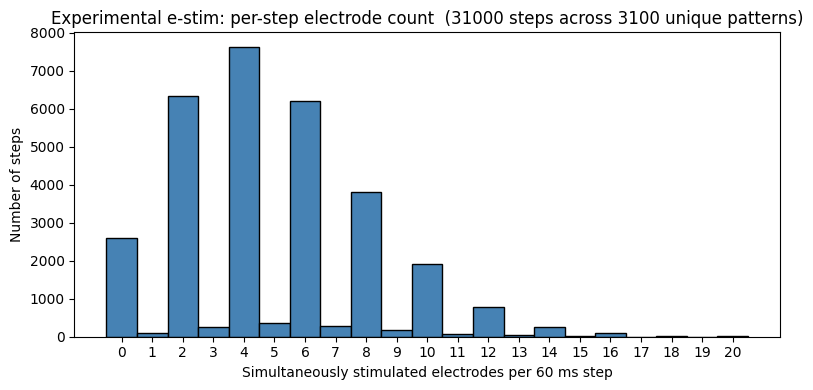

mean = 4.95, median = 4.0, max = 20, n_steps = 31000
(source file has 4000 trial rows, 3100 unique patterns)


In [29]:
# Histogram: number of simultaneously stimulated electrodes per 60 ms step,
# counted across every step of the EXPERIMENT'S e-stim patterns (the ones used
# to train/val/test the model) -- NOT the greedy reconstructions.
# Source: Combined_Pattern_Registrations.pkl.
# "Simultaneous within a step" = unique channels active anywhere in that step
# (NOT per 10 ms bin), so this is just len(step['channel_delays']).
# Deduplicates to unique pattern_name (3100 unique patterns x 10 steps = 31000)
# rather than counting trial replicates.
import pickle
import matplotlib.pyplot as plt

PATTERN_PKL  = f'{datadir}/Combined_Pattern_Registrations.pkl'
DEDUPLICATE  = True  # one entry per unique pattern_name (matches the 3100 figure)

with open(PATTERN_PKL, 'rb') as f:
    experiment_patterns = pickle.load(f)

if DEDUPLICATE:
    seen = {}
    for p in experiment_patterns:
        seen.setdefault(p['pattern_name'], p)
    patterns_to_count = list(seen.values())
else:
    patterns_to_count = experiment_patterns

per_step_counts = np.array([
    len(s['channel_delays'])
    for p in patterns_to_count
    for s in p['steps']
])

max_count = int(per_step_counts.max()) if len(per_step_counts) else 0
bins = np.arange(-0.5, max_count + 1.5, 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_step_counts, bins=bins, color='steelblue', edgecolor='black')
ax.set_xlabel('Simultaneously stimulated electrodes per 60 ms step')
ax.set_ylabel('Number of steps')
ax.set_title(f'Experimental e-stim: per-step electrode count  '
             f'({len(per_step_counts)} steps across {len(patterns_to_count)} '
             f'{"unique patterns" if DEDUPLICATE else "trials"})')
ax.set_xticks(np.arange(0, max_count + 1))
plt.tight_layout()
plt.show()

print(f'mean = {per_step_counts.mean():.2f}, median = {np.median(per_step_counts):.1f}, '
      f'max = {per_step_counts.max()}, n_steps = {len(per_step_counts)}')
print(f'(source file has {len(experiment_patterns)} trial rows, '
      f'{len(set(p["pattern_name"] for p in experiment_patterns))} unique patterns)')
